# ============================================================
#                    Chapter 09 — Functions
# ============================================================

# 🧠 SECTION 1 — Introduction to Functions
## Chapter 9. Functions as Analytical Abstractions

## Why Functions Exist (Beyond “Reusability”)

In analytics, functions are not just a way to avoid copy-paste code.  
They are **abstractions** — named, trusted operations that convert inputs into outputs in a predictable way.

Think of a function as a **mini-pipeline**:

Input data  
→ validation  
→ transformation  
→ output  

This mirrors how real analytics systems work.

Built-in functions like `max()`, `len()`, and `sum()` already follow this pattern.  
Our goal in this chapter is to learn how to **design our own** functions with the same discipline.

---

## The Anatomy of a Function Call

A function has four conceptual parts:

1. **Inputs (Arguments)**  
   Data and configuration values passed into the function

2. **Processing Logic**  
   The work performed on the inputs

3. **Outputs (Return Values)**  
   The result(s) sent back to the caller

4. **Side Effects (Optional)**  
   Actions taken that are not returned (printing, saving files, logging)

Let’s ground this with a familiar built-in example.

---

## Example: `max()` as a Mental Model

```python
# Input data: a list of prices
price_list = [5.99, 19.99, 24.99, 0, 74.99, 99.99]

# Function call
highest_price = max(price_list)

# Output value: 99.99
```

What happened conceptually:

- **Input**: `price_list`
- **Processing**: Python compares all values
- **Output**: `99.99`
- **Side effects**: None

This exact structure is what we will replicate with custom functions.

---

## Why This Matters in Data Analysis

In real analytics work, you routinely:

- Clean data the same way across projects
- Apply consistent business rules
- Transform raw values into standardized outputs
- Validate inputs before analysis

Functions allow you to:

- Encode **business logic once**
- Reuse it safely
- Improve readability of notebooks
- Reduce error rates

A notebook full of functions reads like **documentation**, not just code.

---

## Preview: From Script Thinking to Function Thinking

Compare these two mindsets:

**Script mindset:**  
“Run these steps top to bottom.”

**Function mindset:**  
“Define reliable operations, then compose them.”

The second mindset scales.  
The first does not.

Everything else in this chapter builds on this shift.

---

## Key Takeaways

- Functions are analytical abstractions, not just shortcuts
- Every function follows input → processing → output
- Built-in functions model best practices we should emulate
- Strong function design leads to cleaner, safer analytics workflows
- This chapter is about **thinking in functions**, not memorizing syntax


# 🧠 SECTION 2 — Functions
## Chapter 9. Preview: Defining Custom Functions (Foundations)

## The Purpose of `def`

When you define a function, you are doing three things simultaneously:

1. **Naming a transformation**
2. **Declaring inputs the function expects**
3. **Guaranteeing what the function will return**

In analytics, a function definition is a **contract**:
> “If you give me X (in the correct form), I will reliably give you Y.”

This mindset prevents fragile notebooks and silent errors.

---

## Basic Function Structure

Every function definition follows this structure:

```python
def function_name(parameters):
    """
    Docstring (optional but strongly recommended)
    """
    # processing logic
    return output
```

Key rules:
- `def` starts the definition
- Parameters live inside parentheses
- The colon (`:`) signals a new code block
- `return` explicitly sends a value back to the caller

Without `return`, the function returns `None` by default.

---

## A Minimal, Correct Function

Let’s begin with a deliberately simple function so we can focus on structure.

```python
def add_numbers(a, b):
    """
    Adds two numeric values together.

    Args:
        a (int or float): First number
        b (int or float): Second number

    Returns:
        int or float: Sum of a and b
    """
    total = a + b
    return total
```

Function call:

```python
result = add_numbers(5, 7)
result

# Output: 12
```

What matters here is not the math.  
What matters is **clarity of intent**.

---

# Parameters vs Arguments (Precision Matters)

- **Parameters** are defined in the function signature  
- **Arguments** are the actual values passed during a function call

```python
# parameters: a, b
def multiply(a, b):     # ← Here, 'a' and 'b' are the PARAMETERS
    return a * b

# arguments: 4, 10
result = multiply(4, 10)   # ← Here, 4 and 10 are the ARGUMENTS

# Example:
def greet(name, age):           # parameters: name, age
    print(f"Hello {name}, you are {age} years old.")

greet("Alice", 25)              # arguments: "Alice", 25

# Output: Hello Alice, you are 25 years old.
```
In analytics documentation and team discussions, using these terms correctly matters.

---

## Chapter 9. Section 2: Summary

- `def` creates a named, reusable transformation
- Parameters define expected inputs
- Arguments are supplied at call time
- `return` is mandatory for reusable analytics logic
- Docstrings are part of professional-quality code
- Functions should return data, not print it


In [1]:
# --------------------------------------------
# Defining a Function
# Parameters vs Arguments
# --------------------------------------------
# - **Parameters** are defined in the function signature  
# - **Arguments** are the actual values passed during a function call

def build_greeting(name, age):           # parameters: name, age
    """
    Builds a greeting message.

    Args:
        name (str): Person's name
        age (int): Person's age

    Returns:
        str: Greeting message
    """
    return f"Hello {name}, you are {age} years old."

# Usage:
message = build_greeting("Alice", 25)    # arguments: "Alice", 25
print(message)

# Output: Hello Alice, you are 25 years old.


# --------------------------------------------
# Example 1: Defining a function
# Concatenate two words separated by a space
# --------------------------------------------

def concatenator(string1, string2):
    combined_string = string1 + " " + string2
    return combined_string

# Call function:
concatenator("Hello", "World!")

# Output: 'Hello World!'

# --------------------------------------------
# Example 2: Defining a function
# Tax calculator that takes a subtotal and 
# a tax rate and returns the total invoice amount
# --------------------------------------------
sub_total = 100.00
sales_tax = 0.06

def tax_calc(sub_total, sales_tax):
    """Calculates sales tax for a given subtotal.

    Args:
        sub_total (float): Pre-tax amount
        sales_tax (float): Tax rate as a decimal
    
    Returns:
        float: Tax amount rounded to 2 decimal places
    """
    total = sub_total + (sub_total * sales_tax)
    return round(total, 2)    # ← This rounds to 2 decimal places

# Call function:
total = tax_calc(sub_total, sales_tax)
print(total)  # Output: 106.0

# --------------------------------------------
# Return Values Are the Output Boundary
# A function should return data, not print data
# --------------------------------------------
# Why this matters:
# - Returned values can be reused
# - Printed values cannot
# - Functions should be composable

# Bad analytics practice: ⚠️
def calculate_tax_bad(subtotal, tax_rate):
    print(subtotal * tax_rate)
    
# Correct analytics practice:
def calculate_tax(subtotal, tax_rate):
    """
    Calculates sales tax for a given subtotal.

    Args:
        subtotal (float): Pre-tax amount
        tax_rate (float): Tax rate as a decimal
    
    Returns:
        float: Tax amount rounded to 2 decimal places
    """
    tax = subtotal * tax_rate
    return round(tax, 2)    # ← This rounds to 2 decimal places


# Example usage:
subtotal = 100.00
tax_rate = 0.08
result = calculate_tax(subtotal, tax_rate)
print(result)  # Output: 8.0
print(type(result)) # <class 'float'> There is no difference between 8.00, 8.0, and 8 as a float

# Additional examples:
subtotal = 100.00
tax_rate = 0.08
tax = calculate_tax(subtotal, tax_rate)  # tax is 8.0 (float)
total = subtotal + tax               # Works perfectly: 108.0
print(total)                         # Output: 108.0

# Now you can reuse it in math
total = subtotal + tax                # → 108.0

# And when you want to DISPLAY it nicely:
print(f"Tax: ${tax:.2f}")             # → Tax: $8.00
print(f"Total: ${total:.2f}")         # → Total: $108.00

# ------------------------------------------------------
# Realistic Analytics Usage Example
# ------------------------------------------------------
def calculate_tax_float(subtotal, tax_rate):
    """Simple version using regular floats — easy to understand."""
    tax = subtotal * tax_rate
    return round(tax, 2)          # ← Return a number (float or Decimal)

# Usage:
subtotal = 100.00
tax_rate = 0.08

# Step 1: Compute — keep everything as numbers for reuse
tax = calculate_tax_float(subtotal, tax_rate)   # → 8.0 (float)
total = subtotal + tax                          # → 108.0 (float) — perfect math!

# You can now safely reuse these in further analytics:
average_tax_rate = tax / subtotal               # → 0.08
grand_total_with_discount = total * 0.9         # Apply 10% off, etc.

# Step 2: # And when you want to DISPLAY it nicely:
print(f"Tax: ${tax:.2f}")             # → Tax: $8.00
print(f"Total: ${total:.2f}")         # → Total: $108.00
print(f"Subtotal:  ${subtotal:.2f}")           # → Subtotal:  $100.00
print(f"Tax (8%):   ${tax:.2f}")               # → Tax (8%):   $8.00
print(f"Total:      ${total:.2f}")             # → Total:      $108.00
print("-" * 30)
print(f"Final amount: ${grand_total_with_discount:.2f}")  # → reusable in reports


# ------------------------------------------------------
# Docstrings are embedded documentation
# This is professional discipline, not academic formality
# ------------------------------------------------------
# They are how future you and other analysts understand your work.
# Good docstrings answer:
# - What does this function do?
# - What inputs does it expect?
# - What does it return?

# Realistic Analytics Example:

def usd_to_eur(amount_usd, exchange_rate=0.88):
    """
    Converts a USD amount to EUR using a given exchange rate.

    Args:
        amount_usd (float): Amount in US dollars
        exchange_rate (float, optional): USD to EUR rate. Defaults to 0.88.

    Returns:
        float: Amount converted to euros
    """
    eur_amount = amount_usd * exchange_rate
    return round(eur_amount, 2)

# Usage:
usd_to_eur(150)
usd_to_eur(150, exchange_rate=0.91)


# Key Takeaways

# - `def` creates a named, reusable transformation
# - Parameters define expected inputs
# - Arguments are supplied at call time
# - `return` is mandatory for reusable analytics logic
# - Docstrings are part of professional-quality code
# - Functions should return data, not print it

Hello Alice, you are 25 years old.
106.0
8.0
<class 'float'>
108.0
Tax: $8.00
Total: $108.00
Tax: $8.00
Total: $108.00
Subtotal:  $100.00
Tax (8%):   $8.00
Total:      $108.00
------------------------------
Final amount: $97.20
8.00
8.00
108.00
<class 'decimal.Decimal'>
True


136.5

In [4]:
concatenator?

Signature: concatenator(string1, string2)
Docstring: <no docstring>
File:      c:\users\tripl\appdata\local\temp\ipykernel_13528\2276394690.py
Type:      function

In [4]:
# ------------------------------------------------------
# Currency in Analytics, using the built-in decimal module
# ------------------------------------------------------
# it stores exact decimal values and remembers precision

# Version A — Strict Decimal API (preferred for analytics)

from decimal import Decimal, ROUND_HALF_UP

def calculate_tax_dec(subtotal: Decimal, tax_rate: Decimal = Decimal("0.08")):
    """
    Calculate sales tax using Decimal arithmetic only.

    Contract:
      - Caller MUST pass Decimal values.
      - This avoids all float precision issues by design.
    """
    tax = subtotal * tax_rate
    return tax.quantize(Decimal("0.00"), rounding=ROUND_HALF_UP)

# Example usage:
subtotal = Decimal("100.00")
tax = calculate_tax_dec(subtotal)
total = subtotal + tax

print(tax)     # 8.00
print(total)   # 108.00

# -------------------------------------------------------------------
# Version B - Adapter version (when accepting floats is intentional)
# -------------------------------------------------------------------

from decimal import Decimal, ROUND_HALF_UP

def calculate_tax_safe(subtotal, tax_rate=0.08):
    """
    Calculate sales tax safely when inputs may be float or int.

    Strategy:
      - Convert through str() to discard binary float error.
      - Then use Decimal for exact arithmetic.
    """
    subtotal_dec = Decimal(str(subtotal))
    tax_rate_dec = Decimal(str(tax_rate))

    tax = subtotal_dec * tax_rate_dec
    return tax.quantize(Decimal("0.00"), rounding=ROUND_HALF_UP)

# Easy to use!
tax = calculate_tax_safe(100.00)          # Uses default 8%
print(tax)                               # 8.00

# Usage with Decimal
subtotal = Decimal('100.00')
tax_rate = Decimal('0.08')
tax = calculate_tax_safe(subtotal, tax_rate)
total = subtotal + tax

print(tax)         # → 8.00
print(total)       # → 108.00
print(type(tax))   # <class 'decimal.Decimal'>
print(tax == Decimal('8.00'))  # True



# Key teaching point:
# ⚠️ Why convert through str()?
# Decimal(0.1) preserves the binary float error
# Decimal("0.1") creates the exact decimal value
# Decimal(str(x)) recovers the human-intended number

8.00
108.00
8.00
8.00
108.00
<class 'decimal.Decimal'>
True


# 🧠 SECTION 3 — Functions
## Chapter 9. Defining Custom Functions (Foundations)

## Why Argument Types Matter in Analytics

In analytics, functions rarely operate on *one fixed input*.

They must handle:
- Different data sources
- Optional configuration values
- Varying levels of detail
- Evolving business rules

Argument types are how we design **flexibility without chaos**.

Poorly designed arguments lead to:
- Confusing function calls
- Silent bugs
- Fragile notebooks

Well-designed arguments lead to:
- Self-documenting code
- Safe reuse
- Clean pipelines

---
## Summary:

- Positional arguments are matched by order
- Keyword arguments improve clarity and safety
- Default arguments support flexibility
- `*args` captures variable positional inputs
- `**kwargs` captures variable named inputs
- Argument design is a **core analytics skill**, not just syntax


In [5]:
# --------------------------------------------
# 1️⃣ Positional Arguments (The Default)
# Positional arguments are matched by order
# --------------------------------------------
# Analytics Guidance:
# - Use positional arguments for primary data
# - Keep them few; order them logically

def revenue(price, quantity):
    """
    Calculates total revenue.

    Args:
        price (float): Unit price
        quantity (int): Number of units sold

    Returns:
        float: Total revenue
    """
    return price * quantity


# Usage:
total = revenue(19.99, 3)
print(total)

# -----------------------------
# Positional argument example:
# -----------------------------

def unit_price(total_revenue, quantity):
    """
    Calculates unit price.

    Swapping positional arguments will produce an incorrect result
    without raising an error.

    Args:
        total_revenue (float): Total sales revenue
        quantity (int): Units sold

    Returns:
        float: Unit price
    """
    return total_revenue / quantity   # division, non-communicative

# Correct usage:
price = unit_price(100, 4)
print(price)   # 25.0

# ⚠️ Risk: Order matters:
# This will run, but produces the wrong result
bad_price = unit_price(4, 100)
print(bad_price)  # 0.04 ❌ clearly wrong


# -----------------------------
# Positional argument example:
# -----------------------------

def apply_discount(amount, discount_rate):
    """
    Applies a percentage discount to a monetary amount.

    This function demonstrates asymmetric business logic:
    swapping positional arguments will produce an incorrect result
    without raising an error.

    Args:
        amount (float): Original monetary amount.
        discount_rate (float): Discount rate as a decimal (e.g., 0.10 for 10%).

    Returns:
        float: Discounted amount.
    """
    return amount * (1 - discount_rate)

# Correct usage:
apply_discount(100, 0.10)  # 90.0

# ⚠️ Risk: Order matters:
# This will run, but produces the wrong result
apply_discount(0.10, 100)  # -9.9 ❌ obviously wrong


# --------------------------------------------
# 2️⃣ Keyword Arguments (Clarity Over Brevity)
# Keyword arguments explicitly name each input
# --------------------------------------------
# Analytics Guidance:
# - Prefer keyword arguments for configuration
# - Especially useful when revisiting notebooks months later


def apply_discount(amount, discount_rate):
    """
    Applies a percentage discount to a monetary amount.

    Args:
        amount (float): Original amount.
        discount_rate (float): Discount rate as a decimal (e.g., 0.10 for 10%).

    Returns:
        float: Discounted amount.
    """
    return amount * (1 - discount_rate)

# Correct, readable, order-independent:
total_1 = apply_discount(amount=100, discount_rate=0.10)
total_2 = apply_discount(discount_rate=0.10, amount=100)

print(total_1)  # 90.0
print(total_2)  # 90.0

# Why this matters:
# - Order no longer matters
# - Code reads like documentation
# - Safer for complex functions

# -----------------------------
# Keyword argument example:
# -----------------------------

def gross_revenue(price, quantity):
    """
    Calculates gross revenue.

    Args:
        price (float): Unit price
        quantity (int): Number of units sold

    Returns:
        float: Gross revenue
    """
    return price * quantity

# Correct, readable, order-independent:
gross_revenue(price=19.99, quantity=3)
gross_revenue(quantity=3, price=19.99)

# Note: Because gross_revenue uses multiplication, the numeric result is the same
# either way. The point here is that keyword arguments bind by NAME, improving
# clarity and preventing order-related bugs in general.


# --------------------------------------------
# 3️⃣ Default Arguments (Safe Flexibility)
# --------------------------------------------
# Default arguments allow functions to work out of the box, while still supporting overrides


def usd_to_euro(amount_usd, exchange_rate=0.88):
    """
    Converts USD to EUR.

    Args:
        amount_usd (float): Amount in USD
        exchange_rate (float, optional): Conversion rate

    Returns:
        float: Amount in EUR
    """
    return round(amount_usd * exchange_rate, 2)

# Usage:
usd_to_euro(100)                       # Output: 88.0
usd_to_euro(100, exchange_rate=0.91)   # Output: 91.0


# Rules You Must Remember
# - Default arguments must come last ⚠️
# - Defaults should represent the most common case

# ❌ Invalid
# def bad_example(rate=0.88, amount):
    # pass


# --------------------------------------------
# 4️⃣ `*args` — Variable Positional Arguments
# `*args` allows a function to accept any number 
# of positional inputs (without having to define them), 
# collected as a tuple
# --------------------------------------------
# Analytics Guidance:
# - Use `*args` when the number of inputs is unknown
# - Avoid it when inputs have distinct meanings

# When This Is Useful
# - Aggregations
# - Concatenation
# - Flexible calculations


def average(*values):
    """
    Calculates the average of one or more numeric values.

    Raises:
        ValueError: If no values are provided
    """
    if not values:
        raise ValueError("At least one value is required")
    return sum(values) / len(values)


# Usage:
avg_value = average(10, 20, 30)
print(avg_value)

# What’s happening internally:
# - `*values` is a tuple
# - We can loop, sum, or unpack it


# --------------------------------------------
# Example: *args — Variable Positional Arguments
# --------------------------------------------

def concatenating(*args):
    new_string = ''                 # initialize an empty string to build up over time
    for arg in args:                # start a loop: args == ('Hello', 'world!', 'How', 'are', 'you?')
        new_string += (arg + ' ')   # iterations: new_string += (arg + ' ') appends each word plus a space to the accumulator
    return new_string.rstrip()      # .rstrip() removes trailing whitespace

# Usage:
concatenating("Hello,", "world!", "How", "are", "you?")
# Output: 'Hello, world! How are you?'


# 🟢 Alternatively:🟢 
def pref_concatenate(*words):
    return ' '.join(words)  # joins all strings using a single space as the separator
    
# Usage:    
memo = pref_concatenate("Hello,", "world!", "How", "are", "you?")
print(memo)
# Output: 'Hello, world! How are you?'



# --------------------------------------------
# Mixing normal values with *args
# --------------------------------------------
# Data flow:
#   Call-time inputs  → tuple (*names)
#   Function output   → list[str]
#   Presentation loop → individual strings
#
# Purpose:
#   Separate computation (function) from presentation (printing)

def build_greetings(greeting, *names):
    return [f"{greeting}, {name}!" for name in names]

# Usage:
messages = build_greetings("Hello", "Alice", "Bob", "Charlie")
print(messages)  
# Output: ['Hello, Alice!', 'Hello, Bob!', 'Hello, Charlie!']

for msg in messages:     # for presentation only, not computation
    print(msg)

# Output:
# Hello, Alice!
# Hello, Bob!
# Hello, Charlie!


# --------------------------------------------
# 5️⃣ `**kwargs` — Variable Keyword Arguments
# `**kwargs` accepts any number of named arguments, 
# collected as a dictionary
# --------------------------------------------
# This is extremely powerful in analytics pipelines.
# def concat(**kwargs):
#     """
#     Concatenates keyword argument values into a single string.

#     Returns:
#         str
#     """


def concat(**kwargs):
    new_string = ''                      # initialize an empty string accumulator
    for value in kwargs.values():        # kwargs is a dict: {'a': 'Hello', 'b': 'there!', ...}
        new_string += (value + ' ')      # append each VALUE plus a space
    return new_string.rstrip()           # remove trailing whitespace


# Usage:
lines = concat(a="Hello", b="there!", c="What's", d="up?")
print(lines)
# Output: "Hello there! What's up?"


# 🟢 Alternatively: 🟢 
def pref_concat(**words):
    return ' '.join(words.values())  # joins all strings using a single space as the separator
    
# Usage:    
post = pref_concat(a="Hello", b="there!", c="What's", d="up?")
print(post)
# Output: "Hello there! What's up?"


# ----------------------------------
# Example: `**kwargs` — Named Inputs
# ----------------------------------
# `**kwargs` collects keyword arguments into a DICTIONARY.
# Each key is the argument name, and
# Each value is the argument value.

def summarize_metrics(**metrics):
    """
    Summarizes named metrics.

    Args:
        **metrics (float): Named metric values passed as keyword arguments

    Returns:
        dict: Metrics with values rounded to 2 decimal places
    """
    summary = {}  
    # Initialize an empty dictionary to store the cleaned results

    for key, value in metrics.items():
        # metrics.items() returns (key, value) pairs from the kwargs dictionary
        # Example iteration:
        # key = 'revenue', value = 12345.678

        summary[key] = round(value, 2)
        # Round each metric value and store it under the same key
        # This preserves the original metric names while cleaning the data

    return summary
    # Return structured data (not printed output) for reuse in analytics


# Usage:

metrics = summarize_metrics(
    revenue=12345.678,
    cost=9876.543,
    margin=2469.135
)
# Internally, Python builds this dictionary before the function runs:
# metrics = {
#     'revenue': 12345.678,
#     'cost': 9876.543,
#     'margin': 2469.135
# }

print(metrics)
# Output:
# {'revenue': 12345.68, 'cost': 9876.54, 'margin': 2469.14}

# Why This Is Important:
# - Accepts dynamic inputs
# - Works naturally with dictionaries
# - Ideal for reporting outputs



# ----------------------------------
# Example: Unpacking a dictionary with `**`
# ----------------------------------
# 📦➡️ The `**` operator UNPACKS a dictionary into keyword arguments.
# 🎯 Dictionary KEYS must match the function's parameter names exactly.


def exponentiator(constant, base, exponent):
    """
    Calculates an exponential expression with a scaling constant.

    Args:
        constant (int or float): Multiplier applied to the result
        base (int or float): Base number
        exponent (int): Power to raise the base to

    Returns:
        int or float: Result of constant * (base ** exponent)
    """
    return constant * (base ** exponent)


# Usage:
parameter_dict = {
    "constant": 2,
    "base": 3,
    "exponent": 2
}

# The `**` operator tells Python to:
# 1️⃣ Take each key-value pair in the dictionary
# 2️⃣ Treat each key as a parameter name
# 3️⃣ Pass each value as the corresponding argument
#
# 🔁 This call is equivalent to writing:
# exponentiator(constant=2, base=3, exponent=2)

result = exponentiator(**parameter_dict)
print(result)

# Output:
# 18


#----------------------------------------------
# 🚨 Pro Insight: Argument Ordering Discipline
#-----------------------------------------------
# The correct argument order in professional code is:

# def function_name(
#     required_positional,
#     optional_positional=default,
#     *args,
#     keyword_only=default,
#     **kwargs
# ):
#     pass

# You won’t always use all of these, but you must recognize the pattern.

# Analytics design pattern example
# Demonstrates correct signature ordering discipline:
def tax_calculator(
    subtotal,
    tax_rate=0.06,
    *discounts,
    **metadata
):
    """
    Calculates final total with optional discounts and metadata.

    Args:
        subtotal (float): Base transaction amount
        tax_rate (float, optional): Sales tax rate
        *discounts (float): Any discount amounts
        **metadata: Additional transaction info

    Returns:
        dict: Transaction summary
    """
    # Execution order:
    discounted_total = subtotal - sum(discounts)
    tax = discounted_total * tax_rate
    total = discounted_total + tax
    
    # Return structure order (presentation, not computation):
    return {
    "subtotal": subtotal,
    "discounts": discounts,
    "discounted_total": discounted_total,
    "tax": round(tax, 2),
    "total": round(total, 2),
    "metadata": metadata
}


# Usage:
tax_calculator(
    200,
    0.07,
    10,
    5,
    customer_id="C0042",
    region="Stowe"
)

# This mirrors real ETL-style analytics logic
# metadata allows arbitrary contextual information
# without changing the function signature


# Key Takeaways:
# - Positional arguments are matched by order
# - Keyword arguments improve clarity and safety
# - Default arguments support flexibility
# - `*args` captures variable positional inputs
# - `**kwargs` captures variable named inputs
# - Argument design is a core analytics skill, not just syntax


59.97
25.0
0.04
90.0
90.0
20.0
Hello, world! How are you?
['Hello, Alice!', 'Hello, Bob!', 'Hello, Charlie!']
Hello, Alice!
Hello, Bob!
Hello, Charlie!
Hello there! What's up?
Hello there! What's up?
{'revenue': 12345.68, 'cost': 9876.54, 'margin': 2469.14}
18


{'subtotal': 200,
 'discounts': (10, 5),
 'discounted_total': 185,
 'tax': 12.95,
 'total': 197.95,
 'metadata': {'customer_id': 'C0042', 'region': 'Stowe'}}

# 🧠 SECTION 4 — Functions
## Chapter 9. Return Strategies (Designing Outputs for Reuse)

## Why Return Strategy Matters More Than You Think

In analytics, **what you return** from a function determines:

- How easily results can be reused
- Whether outputs compose cleanly into pipelines
- How readable downstream code becomes
- Whether your logic scales beyond a single notebook cell

A function’s return value is its **public interface**.

Bad return design forces callers to:
- Recompute values
- Rely on globals
- Parse printed output (❌)
- Rewrite logic

Good return design makes functions **lego bricks**.

---

## Rule Zero: Functions Should Return Data, Not Behavior

A function should:
- Return values
- Avoid printing (except debugging)
- Avoid mutating external state

This keeps functions:
- Testable
- Reusable
- Predictable

---

## Design Heuristic: Choosing the Right Return Type 🧭

Ask yourself:

- One value? → scalar
- Multiple values, fixed order, internal use? → tuple
- Iterable output? → list
- Named, reusable analytics output? → dictionary

This decision is **architectural**, not cosmetic.


In [17]:
# 🧠 Lesson: Understanding Return Values

# A function's main job is to **compute** 
# something and **give it back** to the caller using `return`. 
# This lesson shows what return values are, how to use them, and why they matter.

# ============================================
# 1. What is a return value?
# ============================================

# A return value is the result a function sends back to the caller.
# Think of a function like a machine: you put inputs in, it gives an output back.

def square(n):
    """Return the square of n."""
    result = n ** 2
    return result      # <-- this is the return value


# Calling the function and capturing the return value:
answer = square(5)     # answer now holds 25
print(answer)          # 25

# You can also use the return value directly:
print(square(7))       # 49


# ============================================
# 2. ⚠️ print() vs return — they are NOT the same
# ============================================

# ❌ BAD: printing inside the function
def square_bad(n):
    print(n ** 2)      # displays on screen, but returns nothing

output = square_bad(5)  # prints 25
print(output)           # None  ← can't reuse the result!


# ✅ GOOD: returning from the function
def square_good(n):
    return n ** 2       # sends value back to caller

output = square_good(5)
print(output)           # 25 ← now you can use it!

# Why returning is better:
total = square_good(3) + square_good(4)   # 9 + 16 = 25
print(total)                               # 25


# ============================================
# 3. Using return values in expressions
# ============================================

def add(a, b):
    return a + b

def multiply(a, b):
    return a * b

# Chain function calls together:
result = multiply(add(2, 3), add(4, 1))   # multiply(5, 5) → 25
print(result)                              # 25

# Store intermediate results for clarity:
sum1 = add(2, 3)       # 5
sum2 = add(4, 1)       # 5
product = multiply(sum1, sum2)
print(product)         # 25


# ============================================
# 4. Returning multiple values (tuple)
# ============================================

def div_and_remainder(num, divisor):
    """
    Returns BOTH the quotient and remainder when dividing num by divisor.
    Returns a tuple: (quotient, remainder)
    """
    quotient  = num // divisor     # whole number part
    remainder = num % divisor      # what's left over
    return quotient, remainder     # comma = tuple packing (parentheses optional)

# Calling the function and capturing the result
result = div_and_remainder(17, 5)
print("Raw returned value:", result)          # (3, 2)  ← it's a tuple!
print("Type of result:", type(result))        # <class 'tuple'>

# Better: unpack directly into separate variables (very common!)
q, r = div_and_remainder(17, 5)
print("Quotient:", q)                         # 3
print("Remainder:", r)                        # 2


# ============================================
# 5. Early return (exit function immediately)
# ============================================

def first_positive(numbers):
    """Return the first positive number, or None if there are none."""
    for num in numbers:
        if num > 0:
            return num   # exits the function immediately
    return None          # only reached if no positive found


print(first_positive([-3, -1, 0, 4, 7]))   # 4  (first positive)
print(first_positive([-5, -2, 0]))         # None (no positives)


# ============================================
# 6. Practical example: reusable calculations
# ============================================

def tip_amount(bill, tip_percent=15):
    """Calculate tip based on bill total and tip percentage."""
    return bill * (tip_percent / 100)


def total_with_tip(bill, tip_percent=15):
    """Calculate total bill including tip."""
    tip = tip_amount(bill, tip_percent)   # reuse the other function!
    return bill + tip


# Example calls:
my_bill = 45.00

print(f"Tip (15%): ${tip_amount(my_bill):.2f}")              # $6.75
print(f"Tip (20%): ${tip_amount(my_bill, 20):.2f}")          # $9.00
print(f"Total with 15% tip: ${total_with_tip(my_bill):.2f}") # $51.75
print(f"Total with 20% tip: ${total_with_tip(my_bill, 20):.2f}") # $54.00


# **Key takeaways**

# - `return` sends a value **back to the caller**; `print()` just displays something on screen.  
# - If you don't use `return`, the function returns `None` by default, which is usually not useful.  
# - Return values can be stored in variables, used in expressions, or passed to other functions.  
# - Functions can return **multiple values** by packing them into a tuple; the caller can unpack them.  
# - A `return` inside a loop causes an **early exit**, which is useful for "find first" or "stop when condition met" patterns.  
# - Keeping computation in functions (with `return`) and printing outside makes your code **reusable** and easier to test.

25
49
25
None
25
25
25
25
Raw returned value: (3, 2)
Type of result: <class 'tuple'>
Quotient: 3
Remainder: 2
4
None
Tip (15%): $6.75
Tip (20%): $9.00
Total with 15% tip: $51.75
Total with 20% tip: $54.00


In [6]:
# ✅ Return Strategies: Multiple Outputs Without the Mess

# - **clean computation**
# - **explicit return shapes**
# - **caller-controlled presentation**


# 1️⃣ Multiple return values = one tuple (mechanics)

# Python can “return multiple values” because it actually returns **one tuple**.

def sentence_and_last_word(*words):
    """
    Builds a sentence and returns the sentence plus the last word.

    Returns:
        tuple[str, str]: (sentence, last_word)
    """
    if not words:
        raise ValueError("At least one word is required")

    sentence = " ".join(words)     # clean, scalable string building
    last_word = words[-1]          # last item from the tuple of inputs

    return sentence, last_word     # tuple packing

# Usage (tuple unpacking)

sentence, last_word = sentence_and_last_word("Hello", "world!", "How", "are", "you?")
sentence
last_word

## 2️⃣ Better for analytics: return a dictionary (explicit meaning)

# Tuples are fine, but in analytics **meaning should be named**, not positional.

def sentence_summary(*words):
    """
    Returns a structured summary of a sentence-building step.

    Returns:
        dict: {sentence, last_word, word_count}
    """
    if not words:
        raise ValueError("At least one word is required")

    sentence = " ".join(words)     # clean, scalable string building

    return {
        "sentence": sentence,
        "last_word": words[-1],
        "word_count": len(words)
    }

# Usage (robust + readable)

summary = sentence_summary("Hello", "world!", "How", "are", "you?")
summary["sentence"]
summary["last_word"]
summary["word_count"]

# 3️⃣ Presentation happens outside the function (your Rule #1)

# Presentation only (not computation)
print(summary["sentence"])
print(summary["last_word"])
print(summary["word_count"])

# Key Takeaways

# - “Multiple returns” in Python = returning **one tuple**
# - Use `" ".join(...)` instead of manual `+=` in loops
# - Tuple unpacking is fine, but tuples are **order-dependent**
# - For analytics outputs, **dictionaries are preferred** (explicit meaning)
# - Functions return data; callers handle presentation

Hello world! How are you?
you?
5


In [21]:
# 🧠 SECTION — Return Values (Structured Returns & Unpacking) ⭐

# In Python, a function can return **any object**, including:
# - tuples
# - lists
# - dictionaries
# - custom objects

# When you write:
# return a, b
# Python is actually doing:
# return (a, b)   # tuple packing

# This enables a powerful pattern called **multiple return values + unpacking**.

# Think in two phases:
# inside function:   values are PACKED into one object
# outside function: values are UNPACKED into separate variables


# 1️⃣ Returning Multiple Values (Tuple Packing)

def rating_cleaner(rating):
    """
    Extracts the numeric portion from a text rating.

    Args:
        rating (str): Rating like "5 stars"

    Returns:
        tuple: (original_rating, numeric_rating)
    """
    numeric_rating = int(rating[0])      # extract first character and convert to int
    return numeric_rating, rating        # ← tuple packing return 📦 (e.g., return a, b, c)

    
# Usage: capture the returned tuple

website_ratings = ["5 stars", "4 stars", "3 stars"]

result = rating_cleaner("5 stars")

# Internally:
result == (5, "5 stars")

print(result)
print(type(result))     # <class 'tuple'>
print()

# 🧠 Notes:
# - The comma creates a **tuple**
# - Parentheses are optional
# - This is how Python returns “multiple values”


# 2️⃣ Unpacking Returned Tuples (The Real Power)

# Instead of working with the tuple directly, you usually **unpack** it.

rating_text, numeric_rating = rating_cleaner("5 stars")  # tuple unpacking 📤

# Now:
rating_text     == "5 stars"
numeric_rating  == 5

print(rating_text)
print(numeric_rating)


# 🧠 Key ideas:
# - The number of variables on the left must match the tuple length
# - Unpacking is **positional** (order matters) 📤
# - This is extremely common in real code


# 3️⃣ Returning Lists Instead of Tuples

# You can explicitly return a list if mutability or list semantics are desired.

def rating_cleaner_list(rating):
    """
    Returns rating info as a list.

    Returns:
        list: [original_rating, numeric_rating]
    """
    numeric_rating = int(rating[0])
    return [rating, numeric_rating]   #  ← explicit list 📋


# Usage:

data = rating_cleaner_list("4 stars")

print(data)           # ["4 stars", 4]
print(type(data))    # <class 'list'>

# 🧠 Notes:
# - Lists are mutable
# - Meaning is still positional
# - Less common than tuples for fixed-size returns


# 4️⃣ Returning Dictionaries (Preferred for Analytics)

# For analytics, **named fields beat positional order**.

def rating_cleaner_dict(rating):
    """
    Returns rating info as a structured dictionary.

    Returns:
        dict: { "rating": str, "numeric": int }
    """
    numeric_rating = int(rating[0])

    return {
        "rating": rating,              #  ← explicit dictionary
        "numeric": numeric_rating
    }                                  # named fields beat positional order

# Usage:

info = rating_cleaner_dict("3 stars")

print(info)
print(info["rating"])     #  ← safe, explicit access
print(info["numeric"])


# 🧠 Why this is better for analytics:
# - No order dependence
# - Self-documenting
# - Robust to future changes
# - Natural for DataFrames, JSON, APIs


# 5️⃣ Unpacking With Dictionaries vs Tuples
# Tuple unpacking (positional) ⚠️
# Continued in next cell block

(5, '5 stars')
<class 'tuple'>

5
5 stars
['4 stars', 4]
<class 'list'>
{'rating': '3 stars', 'numeric': 3}
3 stars
3


In [23]:
# 5️⃣ Unpacking With Dictionaries vs Tuples 📌
# Tuple unpacking (positional) ⚠️

# This mini‑lesson shows **how unpacking works with tuples**, 
# why **position (order) matters**, and how dictionaries avoid 
# that problem by using **names** instead of positions.

# --------------------------------------------
# The function that returns multiple values
# --------------------------------------------

def rating_cleaner_2(rating):
    """
    Extracts the numeric portion from a text rating.

    Args:
        rating (str): Rating like "5 stars"

    Returns:
        tuple: (numeric_rating, original_rating)
    """
    numeric_rating = int(rating[0])      # take first character, e.g. "5" → 5
    return numeric_rating, rating     # tuple packing return 📦

# --------------------------------------------
# ⚠️ Tuple unpacking — ORDER matters (positional)
# --------------------------------------------
# The function returns: (numeric_rating, original_rating)
# So we MUST unpack in that same order:

website_ratings = ["5 stars", "4 stars", "3 stars"]

numeric_rating, rating_text = rating_cleaner_2("5 stars")
# numeric_rating → 5
# rating_text    → "5 stars"

print("numeric_rating:", numeric_rating)
print("rating_text:   ", rating_text)

# ❌ If we reverse the order, we silently get nonsense:
rating_text_bad, numeric_rating_bad = rating_cleaner_2("4 stars")

print("\nBAD unpacking example:")
print("rating_text_bad:   ", rating_text_bad)    # actually 4 (int), not text
print("numeric_rating_bad:", numeric_rating_bad) # actually "4 stars"

# --------------------------------------------
# Dictionary return — names instead of positions ⭐
# --------------------------------------------

def rating_cleaner_dict(rating):
    """
    Returns rating info as a structured dictionary.

    Returns:
        dict: { "rating": str, "numeric": int }
    """
    numeric_rating = int(rating[0])
    return {
        "rating": rating,          # name: "rating"
        "numeric": numeric_rating  # name: "numeric"
    }  # dict return 🗂


info = rating_cleaner_dict("5 stars")

# Access by key (name), not by position:
rating_text_dict = info["rating"]
numeric_rating_dict = info["numeric"]

print("\nDictionary version:")
print("numeric_rating_dict:", numeric_rating_dict)
print("rating_text_dict:   ", rating_text_dict)

# If we swap these two assignments, the values are still correct,
# - Order-independent
# - Safer for pipelines
# - Preferred in analytics code


# 6️⃣ General Rule: What You Can Return

# A `return` statement can return:

# return 5                        # scalar
# return a, b                     # tuple
# return [a, b]                   # list
# return {"a": a, "b": b}         # dictionary
# return some_object              # any Python object


# The caller receives **exactly one object**.

# If it looks like “multiple values”, it is actually:
# - one tuple
# - being unpacked by the caller


# Key Takeaways

# - `return a, b` returns **one tuple** containing two values  
# - Tuple unpacking lets you bind those values to separate variables  
# - Lists and dictionaries can also be returned  
# - Tuples are positional and order-dependent  
# - Dictionaries are preferred for analytics outputs  
# - Returning structured data makes pipelines safer and clearer  

# > **Return values are not limited to scalars.  
# They define the data interface between functions.**

numeric_rating: 5
rating_text:    5 stars

BAD unpacking example:
rating_text_bad:    4
numeric_rating_bad: 4 stars

Dictionary version:
numeric_rating_dict: 5
rating_text_dict:    5 stars


# 🧠 SECTION 5 — Functions
## Chapter 9. Variable Scope & Lifetime (Data Safety by Design)

## Why Variable Scope Matters in Analytics

Variable scope determines **where a variable exists** and **who can see it**.

In analytics work, poor understanding of scope leads to:
- Silent overwrites
- Hard-to-debug errors
- Fragile notebooks
- Functions that behave differently depending on execution order

Good scope discipline leads to:
- Predictable behavior
- Reusable functions
- Safe pipelines
- Code that scales beyond a single notebook

Scope is not a Python quirk.  
It is a **data safety concept**.

---

## The Two Core Scopes You Must Master

Python introduces many scopes, but for now we focus on the two that matter most:

1. **Local scope** — variables created *inside* a function  
2. **Global scope** — variables created *outside* all functions  


In [27]:
# 🧠 Variable Scope: Practical Examples

# ============================================
# 1️⃣ Local scope: variables live inside functions
# ============================================

def calculate_total(price, quantity):
    total = price * quantity      # total is LOCAL to this function
    return total

print("Order total:", calculate_total(10, 3))   # 30

# This will raise a NameError, because total is not defined here:
# print(total)   # ❌ Uncomment to see the error

# ============================================
# 2️⃣ Global scope: works, but can be fragile
# ============================================

tax_rate = 0.06   # global variable (shared everywhere)

def calculate_tax(subtotal):
    """
    ❗ Fragile version: depends on a global variable `tax_rate`.

    The result can change even if this function's code never changes,
    because it reads tax_rate from the outer/global scope.
    """
    # Uses whatever tax_rate happens to be in the global scope
    return subtotal * tax_rate                 # ⚠️ tax_rate is a global variable


print("\nTax with 6%:", calculate_tax(100))    # 6.0

# Later in the notebook, someone (maybe in a different cell) changes the global:
tax_rate = 0.09    # same name, new value

print("Tax with 9%:", calculate_tax(100))      # 9.0

# 🔍 Same function, different result, just because the GLOBAL tax_rate changed.
# A person reading only calculate_tax() might NEVER see where tax_rate is changed.
# This is how subtle analytics bugs are born!


# ============================================
# ✅ Safer pattern: pass everything in as parameters
# ============================================

def calculate_tax_safe(subtotal, tax_rate):     # ✅ tax_rate is a local variable
    """
    Safe version: tax_rate is an EXPLICIT input.
    Same inputs → same output, no hidden dependency on globals.
    """
    return subtotal * tax_rate


print("\nSafe version (explicit tax_rate):")
print("Tax with 6%:", calculate_tax_safe(100, 0.06))   # 6.0
print("Tax with 9%:", calculate_tax_safe(100, 0.09))   # 9.0

# Anyone reading this call site can SEE which rate is being used.
# No surprises from hidden global variables.


# ============================================
# 3️⃣ global keyword: powerful but dangerous
# ============================================

counter = 0   # global

def increment():
    global counter      # tells Python we mean the global counter ⚠️
    counter += 1        # modifies global state

increment()
increment()
print("\nCounter after two increments:", counter)  # 2

# This kind of hidden mutation makes behavior depend on call order,
# which is risky in analytics notebooks.

# ===========================================================
# Counting INSIDE a function (classic loop counter, SAFE) ✅
# ===========================================================

def count_positives(values):
    """
    Count how many numbers in the list are > 0.
    The counter is local to the function.
    """
    count = 0                  # local counter
    for value in values:
        if value > 0:
            count += 1         # += used safely inside the loop
    return count               # return final count

nums = [-3, 0, 5, 2, -1, 7]
print("Positive count:", count_positives(nums))  # 3
# No globals, no hidden state. Same input → same output.


# ===========================================================
# Increment as a pure helper (SAFE, like add_to_total) ✅
# ===========================================================

def increment_count(current_count, step=1):
    """
    Pure-style increment:
    takes the current count and a step, returns a NEW count.
    """
    return current_count + step   # conceptually the same as current_count += step

count = 0
count = increment_count(count)        # 1
count = increment_count(count)        # 2
count = increment_count(count, 5)     # 7
print("Incremented count:", count)

# ===========================================================
# Example: Count how many ratings are "5 stars" (or higher) in a dataset
# ===========================================================

def count_top_ratings(ratings, top_value="5"):
    """
    Count how many ratings start with a given top_value, e.g. "5" in "5 stars".
    """
    count = 0
    for text in ratings:
        if text.startswith(top_value):
            count += 1          # local counter, safe
    return count


website_ratings = ["5 stars", "4 stars", "5 stars", "3 stars", "5 stars"]

num_fives = count_top_ratings(website_ratings, top_value="5")
print("Number of '5 star' ratings:", num_fives)    # 3

# ===========================================================
# Example where increment_count is realistic: stepping through pages / batches
# ===========================================================

def increment_count(current_index, step=1):
    """
    Pure-style increment:
    takes the current index and a step, returns a NEW index.
    """
    return current_index + step


# Imagine paging through batches of 100 rows in a dataset:
page_index = 0          # start at batch 0
page_index = increment_count(page_index)        # move to batch 1
page_index = increment_count(page_index)        # move to batch 2

print("Current batch index:", page_index)       # 2


# ============================================
# 4️⃣ Name shadowing: local vs global
# ============================================

value = 100   # global

def double_value():
    value = 50          # local variable with the SAME NAME
    return value * 2    # uses local value (50), not global (100)

result = double_value()
print("\nResult from double_value():", result)  # 100 (50 * 2)
print("Global value still:", value)             # 100

# Inside the function, 'value' refers to the local one.
# The global 'value' is unchanged.


# ============================================
# 5️⃣ Safe analytics-style function (no leaks)
# ============================================

def compute_metrics(values):
    """
    Computes summary metrics from a list of values.

    Args:
        values (list of float): Input values

    Returns:
        dict: Summary statistics
    """
    count = len(values)
    total = sum(values)
    average = total / count if count > 0 else 0.0

    return {
        "count": count,
        "total": total,
        "average": round(average, 2),
    }

data = [1, 2, 3, 4]

metrics = compute_metrics(data)
print("\nMetrics:", metrics)

# No globals modified, no hidden state:
# - If you call compute_metrics(data) again, you get the same result.
# - Safe to reuse in other notebooks and pipelines.

# **Key patterns illustrated**

# - Local variables (like `total` inside `calculate_total`) do **not** exist outside their function.  
# - Globals (like `tax_rate`, `counter`, `value`) can be read from functions, but relying on them makes behavior depend on external state.  
# - The `global` keyword lets a function modify a global, but this creates hidden side effects and order‑dependent bugs.  
# - The preferred analytics pattern is: **functions take inputs and return outputs**, with no mutation of external variables.  
# - Name shadowing shows why reusing global names inside functions is confusing—descriptive, local names are safer.  
# - A function like `compute_metrics` is “analytics‑grade”: predictable, testable, and ready to drop into a pipeline.

Order total: 30

Tax with 6%: 6.0
Tax with 9%: 9.0

Safe version (explicit tax_rate):
Tax with 6%: 6.0
Tax with 9%: 9.0

Counter after two increments: 2
Positive count: 3
Incremented count: 7
Number of '5 star' ratings: 3
Current batch index: 2

Result from double_value(): 100
Global value still: 100

Metrics: {'count': 4, 'total': 10, 'average': 2.5}


# 🧠 SECTION 6 — Functions
## Creating Modules & Reuse (From Notebook to Asset)

## Why Modules Matter in Analytics

In real analytics work, notebooks are often:
- Exploratory
- Iterative
- Messy by design

Modules, on the other hand, are:
- Stable
- Reusable
- Shareable
- Testable

A **module** is simply a `.py` file that contains functions (and sometimes constants).
The moment you move logic into a module, you are declaring:

> “This logic is trusted and reusable.”

This is a major professional shift.

---

## Mental Model: Notebook vs Module

Think of it this way:

- **Notebook** → analysis, experimentation, storytelling
- **Module** → utilities, helpers, business logic

Not everything belongs in a module.
But anything you expect to reuse **does**.

---

## Lifecycle of a Module

* Create / overwrite module with %%writefile
* Import module
* Reload after edits with importlib.reload
* Call functions
* Observe outputs

## Keep

* Each step in its own cell
* Each step documented in Markdown
* No mixed concerns

## Writing pricing_utils.py at the top of a new cell
- %%writefile pricing_utils.py

In [44]:
%%writefile pricing_utils.py
def apply_discount(price, discount_rate=0.10):
    """
    Applies a discount to a price.

    Args:
        price (float): Original price
        discount_rate (float): Discount rate as a decimal

    Returns:
        float: Discounted price
    """
    discounted_price = price * (1 - discount_rate)
    return round(discounted_price, 2)


Writing pricing_utils.py


## Importing pricing_utils.py in a new cell
* And testing it

In [45]:
import pricing_utils
pricing_utils.apply_discount(100)

90.0

## Overwriting pricing_utils.py

In [48]:
%%writefile pricing_utils.py

def apply_discount(price, discount_rate=0.10):
    """
    Applies a discount to a price.
    """
    return round(price * (1 - discount_rate), 2)


def add_tax(price, tax_rate=0.06):
    """
    Adds tax to a price.
    """
    return round(price * (1 + tax_rate), 2)

Overwriting pricing_utils.py


## Throw away the cached version and re-read the file from disk
- import importlib
- import pricing_utils
- importlib.reload(pricing_utils)

In [54]:
import importlib
import pricing_utils

importlib.reload(pricing_utils)

pricing_utils.add_tax(100)
pricing_utils.apply_discount(100, 0.15)

85.0

## Selective import - Importing specific functions directly into the namespace

In [59]:
from pricing_utils import add_tax

add_tax(100)

106.0

In [50]:
%%writefile transaction_utils.py

def process_transaction(subtotal, tax_rate=0.06, discount_rate=0.0):
    """
    Processes a transaction and returns a structured summary.

    Args:
        subtotal (float): Base transaction amount
        tax_rate (float): Sales tax rate
        discount_rate (float): Discount rate

    Returns:
        dict: Transaction summary
    """
    discounted = subtotal * (1 - discount_rate)
    tax = discounted * tax_rate
    total = discounted + tax

    return {
        "subtotal": round(subtotal, 2),
        "discounted": round(discounted, 2),
        "tax": round(tax, 2),
        "total": round(total, 2)
    }

Writing transaction_utils.py


In [52]:
import transaction_utils

transaction_utils.process_transaction(200, discount_rate=0.1)

{'subtotal': 200, 'discounted': 180.0, 'tax': 10.8, 'total': 190.8}

## Safeguard to avoid ever importing the wrong file by accident

In [58]:
import pricing_utils
print(pricing_utils.__file__)

C:\Users\tripl\pricing_utils.py


In [57]:
# ======================================================
# Creating & Importing Modules: 
# Writing, Importing, Overwriting, 
# Clearing Cached Version, and Re-reading the file from disk
# (Each step executed in clean cells -- shown above)
# ======================================================
# %%writefile pricing_utils.py

# Step 1️⃣ — Creating a Module from a Notebook
# In Jupyter, we use the `%%writefile` magic command to create a `.py` file.


# def apply_discount(price, discount_rate=0.10):
#     """
#     Applies a discount to a price.

#     Args:
#         price (float): Original price
#         discount_rate (float): Discount rate as a decimal

#     Returns:
#         float: Discounted price
#     """
#     discounted_price = price * (1 - discount_rate)
#     return round(discounted_price, 2)

# What just happened:
# - A file named `pricing_utils.py` was created
# - The function is now **persisted on disk**
# - It can be imported into any notebook in the same directory


# Step 2️⃣ — Importing a Module

# Option A: Import the Entire Module (Preferred) ✅
# Usage:

# import pricing_utils

pricing_utils.apply_discount(100)

# Why this is good practice:
# - Prevents naming conflicts
# - Makes function origin explicit
# - Scales well as modules grow


# Option B: Import Specific Functions (Use Carefully) ⚠️
# Usage:

# from pricing_utils import apply_discount

apply_discount(100)

# ⚠️ Risk:
# - Easy to lose track of where functions come from
# - Can shadow other names accidentally

# Analytics Rule of Thumb
# - Use `import module_name` for shared or growing code
# - Use `from module import function` sparingly


# Step 3️⃣ — Multiple Functions per Module (Best Practice)
# Modules should group **related logic**.


# %%writefile pricing_utils.py

def apply_discount(price, discount_rate=0.10):
    """
    Applies a discount to a price.
    """
    return round(price * (1 - discount_rate), 2)


def add_tax(price, tax_rate=0.06):
    """
    Adds tax to a price.
    """
    return round(price * (1 + tax_rate), 2)

# Usage:

# import pricing_utils

pricing_utils.add_tax(100)
pricing_utils.apply_discount(100, 0.15)

# This is how **helper libraries** begin to form.


# Step 4️⃣ — Designing Modules for Analytics Pipelines
# Let’s design a module that returns **structured outputs**.

# %%writefile transaction_utils.py

def process_transaction(subtotal, tax_rate=0.06, discount_rate=0.0):
    """
    Processes a transaction and returns a structured summary.

    Args:
        subtotal (float): Base transaction amount
        tax_rate (float): Sales tax rate
        discount_rate (float): Discount rate

    Returns:
        dict: Transaction summary
    """
    discounted = subtotal * (1 - discount_rate)
    tax = discounted * tax_rate
    total = discounted + tax

    return {
        "subtotal": round(subtotal, 2),
        "discounted": round(discounted, 2),
        "tax": round(tax, 2),
        "total": round(total, 2)
    }

# Usage:

# import transaction_utils

transaction_utils.process_transaction(200, discount_rate=0.1)

# This is **ETL-style thinking**:
# - Input → transformation → structured output


# Naming Discipline (Critical) 📌

# File Names
# - lowercase
# - underscores
# - descriptive

# Good:
# pricing_utils.py
# date_helpers.py
# validation_tools.py


# Bad:
# Stuff.py
# MyFunctionsFINAL_v3.py


# Function Names
# - verbs for actions
# - nouns for data builders

# Good:
# calculate_margin
# build_summary
# clean_price


# Where Modules Live (Important for Later) 📌

# For now:
# - Modules live in the **same folder** as your notebook

# Later (future you):
# - You’ll organize helpers into folders
# - You’ll manage environments
# - You’ll version-control these files


## Common Anti-Patterns to Avoid

# ❌ Saving logic only in notebooks  
# ❌ Copy-pasting helper code across notebooks  
# ❌ Using globals inside modules  
# ❌ Treating modules as “advanced”  

# Modules are not advanced.
# They are **necessary**.

{'subtotal': 200, 'discounted': 180.0, 'tax': 10.8, 'total': 190.8}

## Exercise: Creating a Module

In [77]:
%%writefile tax_calculations.py
def tax_calculations(subtotal, tax_rate=0.06):
    """
    takes in a subtotal and tax rate and returns total owed.

    Args:
        subtotal (float): Base transaction amount
        tax_rate (float, optional): Sales tax rate defaults to .06.

    Returns:
        list: list containing subtotal, tax, and total
    """
    tax = round(subtotal * tax_rate, 2)
    total = round(subtotal + tax, 2)

    return [round(subtotal, 2), tax, total]

Overwriting tax_calculations.py


## Rename the function inside of the module (i.e., tax_breakdown) then import

In [79]:
import importlib
import tax_calculations

importlib.reload(tax_calculations)

<module 'tax_calculations' from 'C:\\Users\\tripl\\tax_calculations.py'>

In [80]:
subtotals = [15.98, 899.97, 799.97, 117.96, 5.99, 599.99]

full_transactions = []

for subtotal in subtotals:
    full_transactions.append(
        tax_calculations.tax_breakdown(subtotal, tax_rate=0.10))  # reference to the module name and specific function
    
full_transactions

[[15.98, 1.6, 17.58],
 [899.97, 90.0, 989.97],
 [799.97, 80.0, 879.97],
 [117.96, 11.8, 129.76],
 [5.99, 0.6, 6.59],
 [599.99, 60.0, 659.99]]

In [81]:
customer_ids = ["C00004", "C00007", "C00015", "C00016", "C00020", "C00010"]

customer_dictionary = dict(zip(customer_ids, full_transactions))

customer_dictionary

{'C00004': [15.98, 1.6, 17.58],
 'C00007': [899.97, 90.0, 989.97],
 'C00015': [799.97, 80.0, 879.97],
 'C00016': [117.96, 11.8, 129.76],
 'C00020': [5.99, 0.6, 6.59],
 'C00010': [599.99, 60.0, 659.99]}

# 🧠 SECTION 7 — Functions
## Chapter 9. External Imports & Packages (Using the Ecosystem Safely)

## Why External Packages Matter in Analytics

Python is powerful not because of the core language alone, but because of its **ecosystem**.

Analytics work routinely depends on:
- Mathematical functions
- Date/time utilities
- File I/O helpers
- Data manipulation libraries

These capabilities live in **external modules and packages**, not in your notebook.

Your responsibility as an analyst is not to memorize them —  
it is to **import them correctly, safely, and transparently**.

---

## Terminology (Precise but Practical)

- **Module** → a single `.py` file  
- **Package** → a collection of modules  
- **Library** → a collection of packages (term used loosely)

Example:
- `math` → module
- `datetime` → package
- `pandas` → library (contains many packages and modules)

In [20]:
import math
# Beware of naming conflicts in your own functions
# import math as m for an alias helps avoid naming conflicts

number = 25
square_root = math.sqrt(number)
print(f"The square root of {number} is {square_root}")

# Calculate the natural logarithm (base e) of a number
ln_value = math.log(10)
print(f"Natural logarithm of 10: {ln_value}")

# Calculate the logarithm to a specific base
log_base_2 = math.log(8, 2)
print(f"Logarithm of 8 to base 2: {log_base_2}")


log_base_10 = math.log(100, 10)
print(f"Logarithm of 100 to base 10: {log_base_10}")

log_p = math.log1p(100)  # Returns the natural logarithm of 1 + x
print(f"Logarithm of 10: {log_p}")
# useful for small values of x where precision matters

The square root of 25 is 5.0
Natural logarithm of 10: 2.302585092994046
Logarithm of 8 to base 2: 3.0
Logarithm of 100 to base 10: 2.0
Logarithm of 10: 4.61512051684126


In [29]:
# ----------------------------------------------------
# Installing Packages - (many come preinstalled)
# ----------------------------------------------------
# '!' means you can use the command line via Jupyter
# 'conda' is a package manager for Python
# 'install' tells Python to install the package
# 'openpyxl' is the name of the package to install
# adding 'import sys' ensures the package gets installed correctly

# import sys
# ! conda install --yes --prefix {sys.prefix} openpyxl

# To install a specific version: `package_name=1.2.43` 
# import sys
# ! conda install --yes --prefix {sys.prefix} openpyxl package_name=1.2.3

# When you don't know what a package contains (or use Environments tab in Anaconda):
import math
dir(math)

# Essential packages for analytics
# * NumPy  - makes processing data efficient
# * pandas - works on top of NumPy with a tabular data structure
# * matplotlib - static visualizations
# * seaborn - static visulaizations
# * plotly - interactive visualizations

['__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'acos',
 'acosh',
 'asin',
 'asinh',
 'atan',
 'atan2',
 'atanh',
 'cbrt',
 'ceil',
 'comb',
 'copysign',
 'cos',
 'cosh',
 'degrees',
 'dist',
 'e',
 'erf',
 'erfc',
 'exp',
 'exp2',
 'expm1',
 'fabs',
 'factorial',
 'floor',
 'fma',
 'fmod',
 'frexp',
 'fsum',
 'gamma',
 'gcd',
 'hypot',
 'inf',
 'isclose',
 'isfinite',
 'isinf',
 'isnan',
 'isqrt',
 'lcm',
 'ldexp',
 'lgamma',
 'log',
 'log10',
 'log1p',
 'log2',
 'modf',
 'nan',
 'nextafter',
 'perm',
 'pi',
 'pow',
 'prod',
 'radians',
 'remainder',
 'sin',
 'sinh',
 'sqrt',
 'sumprod',
 'tan',
 'tanh',
 'tau',
 'trunc',
 'ulp']

In [26]:
!conda list


# packages in environment at C:\Users\tripl\anaconda3:
#
# Name                             Version              Build                Channel
_anaconda_depends                  2025.06              py313_mkl_2
aext-assistant                     4.20.0               py313haa95532_jl4_0
aext-assistant-server              4.20.0               py313haa95532_0
aext-core                          4.20.0               py313haa95532_jl4_0
aext-core-server                   4.20.0               py313haa95532_0
aext-environments-server           4.20.0               py313haa95532_0
aext-panels                        4.20.0               py313haa95532_0
aext-panels-server                 4.20.0               py313haa95532_0
aext-project-filebrowser-server    4.20.0               py313haa95532_0
aext-share-notebook                4.20.0               py313haa95532_0
aext-share-notebook-server         4.20.0               py313haa95532_0
aext-shared                        4.20.0               py313h

In [39]:
import numpy as np

In [40]:
subtotals = [15.98, 899.97, 799.97, 117.96, 5.99]

In [41]:
np.mean(subtotals)

np.float64(367.97400000000005)

In [38]:
import sys
!conda install --yes --prefix {sys.prefix} matplotlib

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.



In [42]:
import matplotlib.pyplot as plt

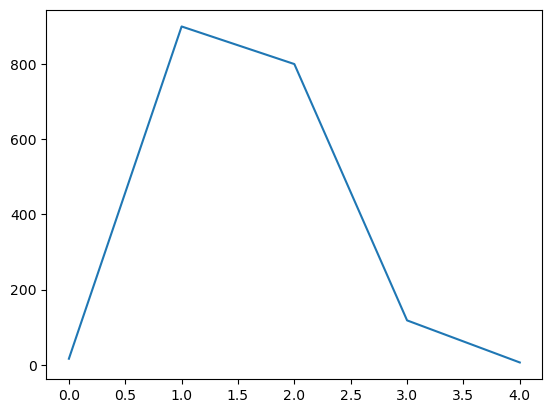

In [43]:
plt.plot(subtotals)

# 🧠 SECTION 8 — Functions
## Chapter 9. `map()` & Function Application (Scaling Clean Logic)

## Why This Section Exists

In analytics, you rarely apply logic to a single value.

You apply the **same transformation** to:
- Every row in a dataset
- Every transaction in a list
- Every value in a column

The question is not *whether* to scale logic —  
it is **how to do so clearly and safely**.

`map()` is one such mechanism.

---

## What `map()` Actually Does

The `map()` function applies a function to **each element** in an iterable.

Syntax:
```python
map(function_name, iterable_name)
```

Important:
- `map()` does **not** immediately return a list
- It returns a **map object**

In [57]:
import importlib
import tax_calculations

importlib.reload(tax_calculations)

<module 'tax_calculations' from 'C:\\Users\\tripl\\tax_calculations.py'>

In [60]:
from tax_calculations import tax_breakdown

In [69]:
subtotals_list = [1799.99, 99.98, 254.99, 29.95, 99.99]
map(tax_breakdown, subtotals_list)

results = (map(tax_breakdown, subtotals_list))
results

In [100]:
subtotals_list = [1799, 99, 254, 29, 99]
list(map(tax_breakdown, subtotals_list))

# To adjust the tax rate with lambda, use: 🧭
results = (map(lambda s: tax_breakdown(s, 0.07), subtotals_list))
results

In [76]:
# Reload module if needed
import importlib
import tax_calculations
importlib.reload(tax_calculations)

from tax_calculations import tax_breakdown

subtotals_list = [1799.99, 99.98, 254.99, 29.95, 99.99]  # input

results = list(map(tax_breakdown, subtotals_list))      # transformation

for r in results:                                       # consumption or presentation
    print(r)

[1799.99, 108.0, 1907.99]
[99.98, 6.0, 105.98]
[254.99, 15.3, 270.29]
[29.95, 1.8, 31.75]
[99.99, 6.0, 105.99]


# 🟢 Refer to SECTION 8 - Functions - Chapter 9 for full markdown lecture

---

# 🧠 SECTION 8 — Functions
## Chapter 9. `map()` & Function Application (Scaling Clean Logic)

## Why This Section Exists

In analytics, you rarely apply logic to a single value.

You apply the **same transformation** to:
- Every row in a dataset
- Every transaction in a list
- Every value in a column

The question is not *whether* to scale logic —  
it is **how to do so clearly and safely**.

`map()` is one such mechanism.

---

## What `map()` Actually Does

The `map()` function applies a function to **each element** in an iterable.

Syntax:
```python
map(function, iterable)
```

Important:
- `map()` does **not** immediately return a list
- It returns a **map object** (lazy evaluation)

In [101]:
# ------------------------------------------------------------------
# Lecture: Understanding map() – Applying a Function to Every Item
# ------------------------------------------------------------------
# **Core idea:**  
# `map(function, iterable)` runs the same function on **every item**
# for any iterable and returns a map object containing the results.

# This is super useful for transforming data without writing explicit loops

# Basic Pattern:

# Define a function that transforms ONE item
def currency_formatter(number):
    """
    Convert a number to a dollar-string format.
    Example: 19.99 → '$19.99'
    """
    return '$' + str(number)

# A list of prices (iterable)
price_list = [5.99, 19.99, 24.99, 0, 74.99, 99.99]

# map() applies the function to EVERY element
# It returns a map object (lazy / iterator – doesn't compute until needed)
formatted_map = map(currency_formatter, price_list)

# See the map object (not very useful by itself)
print(formatted_map)          # <map object at 0x...>

# Convert to a list to see the results
formatted_prices = list(formatted_map)
print(formatted_prices)
# Output: ['$5.99', '$19.99', '$24.99', '$0', '$74.99', '$99.99']


# Alternative Options:

# 1. Using a lambda (anonymous function) – very typical
formatted_prices_lambda = list(map(lambda n: f"${n:.2f}", price_list))
print(formatted_prices_lambda)
# ['$5.99', '$19.99', '$24.99', '$0.00', '$74.99', '$99.99']

# 2. Combining with other functions (real pipeline example)
discounted = list(map(lambda p: round(p * 0.9, 2), price_list))  # 10% off
print(discounted)
# [5.39, 17.99, 22.49, 0.0, 67.49, 89.99]

# 3. Preferred method: list comprehension (cleaner than map + lambda) ⭐
formatted = [f"${p:.2f}" for p in price_list]
print(formatted)

# ---------------------------------------------------
# Comparison: `map()` version vs. list comprehension
# ---------------------------------------------------

# map() version
def currency_format(p):
    return f"${p:.2f}"

map_version = list(map(currency_format, price_list))

# list comprehension version (same result)
comp_version = [f"${p:.2f}" for p in price_list]

print("map() result:   ", map_version)
print("comp result:    ", comp_version)
# Both give: ['$5.99', '$19.99', '$24.99', '$0.00', '$74.99', '$99.99']

['$5.99', '$19.99', '$24.99', '$0', '$74.99', '$99.99']
['$5.99', '$19.99', '$24.99', '$0.00', '$74.99', '$99.99']
[5.39, 17.99, 22.49, 0.0, 67.49, 89.99]
['$5.99', '$19.99', '$24.99', '$0.00', '$74.99', '$99.99']
map() result:    ['$5.99', '$19.99', '$24.99', '$0.00', '$74.99', '$99.99']
comp result:     ['$5.99', '$19.99', '$24.99', '$0.00', '$74.99', '$99.99']


In [96]:
# -----------------------------------------------------
# Lambda Functions
# -----------------------------------------------------
# Lambda functions are **anonymous** (unnamed) functions, typically used for short, throwaway logic.  
# You’ll most often see them when manipulating lists, Series, or columns in pandas DataFrames.

# Mental model:

# General lambda pattern
# lambda x: expression

# is equivalent to:

# def f(x):
#     return expression

# Key idea: a lambda is just a tiny function defined *in place*, usually without giving it a name
# lambdas return the value of the expression automatically
# Model: expression → returned value

# ------------------------------------------------
# Basic lambda usage
# ------------------------------------------------

# Single-argument lambda, called immediately
(lambda x: x**2)(3)          # 9

# ❌ NOT allowed: multiple expressions inside a lambda
# (lambda x: x**2, x**3)(3) # Invalid syntax: a lambda must contain exactly ONE expression


# Multiple arguments + conditional logic
(lambda x, y: x * y if y > 5 else x / y)(6, 5)   # 1.2

# Notes:
# - A lambda can take multiple parameters.
# - It can use conditional expressions (`a if condition else b`).
# - It must always evaluate to a **single** expression (no assignments, loops, or multiple return values inside)

# ------------------------------------------------
# Lambda with map(): currency conversion example
# ------------------------------------------------

price_list = [5.99, 19.99, 24.99, 0, 74.99, 99.99]
ex_rate = 0.88  # example exchange rate

# Apply the exchange rate and round to 2 decimals
converted = map(lambda x: round(x * ex_rate, 2), price_list)

converted_prices = list(converted)
print(converted_prices)

# Here:
# - `map()` applies the lambda to every element in `price_list`.
# - The lambda multiplies each price by `ex_rate` and rounds it.
# - `map()` returns an iterator, so we wrap it in `list()` to see the results

# ------------------------------------------------
# Exercise: Lambda + map() + conditional logic
# Apply a 10% discount to customers who spent > $500
# ------------------------------------------------

subtotaling = [15.98, 899.97, 799.97, 117.97, 5.99, 599.99]

# Standalone lambda line is just to show the pattern;
# by itself it does nothing until we call it

lambda s: round(s * 0.9, 2) if s > 500 else s

# Use map() to apply the lambda to every value in the list
discounted_subtotals = list(map(lambda s: round(s * 0.9, 2) if s > 500 else s,subtotaling))
print(discounted_subtotals)

# Customers who qualify for the discount (based on original spend)
for subtotal in subtotaling:
    if subtotal > 500:
        print(subtotal)

# Optional: Track BOTH Orignial and Discounted Together:
subtotaling = [15.98, 899.97, 799.97, 117.97, 5.99, 599.99]

discounted_subtotals = list(
    map(lambda s: round(s * 0.9, 2) if s > 500 else s, subtotaling)
)

# Zip original and discounted so you can see both
for original, discounted in zip(subtotaling, discounted_subtotals):
    if original > 500:   # qualification is based on original spend
        print(f"Original: {original}, Discounted: {discounted}")

# -----------------------------------------------------
# Equivalent transformation using a list comprehension:
# -----------------------------------------------------
converted_prices_lc = [round(x * ex_rate, 2) for x in price_list]

# map() + lambda and list comprehensions are often interchangeable;
# choice is mostly about readability and style.
        
# Key takeaways
# - Lambda functions are short, **anonymous** functions defined with `lambda`.
# - They are perfect for one-off logic passed into tools like `map()`, `filter()`, or pandas `.apply()`.
# - A lambda must be a **single expression** (no statements like `for`, `while`, or assignments).
# - For anything complex or reusable, prefer a regular `def` function with a clear name.

[5.27, 17.59, 21.99, 0.0, 65.99, 87.99]
[15.98, 809.97, 719.97, 117.97, 5.99, 539.99]
899.97
799.97
599.99
Original: 899.97, Discounted: 809.97
Original: 799.97, Discounted: 719.97
Original: 599.99, Discounted: 539.99


# 🧠 SECTION 9 — Functions
## Chapter 9. Comprehensions (Readable, Scalable Function Consumption)

## Why Comprehensions Matter More Than `map()`

Comprehensions are not just syntactic sugar.

They are:
- Explicit
- Readable
- Flexible
- Pipeline-friendly

In analytics, comprehension syntax often mirrors how we *think*:
> “For each value, apply this transformation, optionally filter, and collect the result.”

This clarity is why comprehensions are usually preferred over `map()`.

---

## The Core Comprehension Pattern

### List Comprehension Syntax

```python
[expression for item in iterable]
```

Think of it as:
- **expression** → what to produce
- **item** → each element
- **iterable** → the data source


In [131]:
# -------------------------------------------
# Comprehensions
# Generate sequences from other sequences
# -------------------------------------------
# Syntax: new_list = [expression for item in iterable (if condition)]


# Example: Creating a list of Euro prices from USD prices
xchange_rate = 0.88 
us_list = [5.99, 9.99, 24.99, 99.99, 0]

uro_list = [round(price * xchange_rate, 2) for price in us_list]
uro_list

# Contrast with using a for loop to create a new list
eur_list = []

for price in us_list:
    eur_list.append(round(price * xchange_rate, 2))
eur_list

# Comprehension with conditional logic and adding if filtering 
uro_list = [round(price * xchange_rate, 2) for price in us_list if price <= 9.99]
uro_list

[5.27, 8.79, 0.0]

In [109]:
import numpy as np

In [111]:
star_ratings = ["5 star", "1 star", "3 star", "4 star", "3 star", "5 star"]

In [115]:
num_rating = [int(rating[0]) for rating in star_ratings]  # for every rating in ratings, store rating index in list
num_rating

[5, 1, 3, 4, 3, 5]

In [119]:
np.mean(num_rating)

np.float64(3.5)

In [123]:
np.mean(lower_ratings)

np.float64(2.3333333333333335)

In [135]:
# ❌ Anti-pattern: recomputes extraction twice per element (avoid)
lower_ratings = [int(rating[0]) for rating in star_ratings if int(rating[0]) < 4]


# ✅ Good pattern: compute once, then filter (generator inside comprehension)
lower_ratings = [
    r
    for r in (int(rating[0]) for rating in star_ratings)
    if r < 4
]


# ✅ Best for teaching and debugging: explicit loop with intermediate variable
lower_ratings = []
for rating in star_ratings:
    r = int(rating[0])      # extract once
    if r < 4:              # then filter
        lower_ratings.append(r)

# Teaching note:
# - All three produce the same result.
# - Prefer the explicit loop for teaching and debugging.
# - Prefer comprehensions when the logic is simple and clear.

In [136]:
# Exerise: List Comprehensions

# Example data for dictionary

item_ids = [
    10001, 10002, 10003, 10004, 10005, 
    10006, 10007, 10008, 10009
]

item_names = [
    "Coffee", "Beanie", "Gloves", "Sweatshirt", "Helmet",
    "Snow Pants", "Coat", "Ski Poles", "Ski Boots"
]

euro_prices = [
    5.27, 8.79, 17.59, 21.99, 87.99, 
    70.39, 105.59, 87.99, 175.99
]

item_category = [
    "beverage", "clothing", "clothing", "clothing", "safety",
    "clothing", "clothing", "hardware", "hardware",
]

all_sizes = [
    ["250mL"],
    ["Child", "Adult"],
    ["Child", "Adult"],
    ["XS", "S", "M", "L", "XL", "XXL"],
    ["Child", "Adult"],
    ["XS", "S", "M", "L", "XL", "XXL"],
    ["S", "M", "L"],
    ["S", "M", "L"],
    [5, 6, 7, 8, 9, 10, 11],
    ["S", "M", "L"],
    [5, 6, 7, 8, 9, 10, 11],
    ["NA"],
    ["S", "M", "L", "Powder"],
]


# Dictionary Comprehension:

euro_data = {
    item_id: [name, price, category, size_list]
    for item_id, name, price, category, size_list in zip(
        item_ids, item_names, euro_prices, item_category, all_sizes
    )
}

euro_data

# for every value in euro_data.values, store values in a list
[value for value in euro_data.values()]

# Calculate the total cost of items
[value[1] for value in euro_data.values()]  # index 1
sum([value[1] for value in euro_data.values()])  # sum function


lower_ratings = []
for rating in star_ratings:
    r = int(rating[0])
    if r < 4:
        lower_ratings.append(r)


In [134]:
# List comprehension vs map + lambda produce the same result

uro_list_lc = [round(price * xchange_rate, 2) for price in us_list]

uro_list_map = list(map(lambda x: round(x * xchange_rate, 2), us_list))

uro_list_lc, uro_list_map

# Both forms are equivalent.
# In Python, list comprehensions are often preferred for readability.

# Important:
# - A list comprehension ALWAYS creates a new list.
# - It does not modify the original list in place.

([5.27, 8.79, 21.99, 87.99, 0.0], [5.27, 8.79, 21.99, 87.99, 0.0])

# 🟢 Refer to SECTION 10 - Functions - Chapter 9 for full markdown lecture
## The full analytics pipeline model relies on key patterns

---

# 🧠 SECTION 10 — Functions
## Chapter 9. Analytics Workflow Patterns (Composing Real Pipelines)

## Why This Section Exists

Up to this point, we have learned *mechanics*:
- Defining functions
- Designing arguments
- Choosing return strategies
- Managing scope
- Creating modules
- Applying functions with `map()` and comprehensions

This section answers the real question:

> **How do analysts actually use all of this together?**

The answer is **composition**.

Good analytics code is not one big function.
It is a sequence of **small, trusted transformations**.

---

## The Analytics Pipeline Mental Model

Most analytics workflows follow this shape:

1. **Ingest** raw inputs  
2. **Clean** and normalize data  
3. **Validate** assumptions  
4. **Transform** values  
5. **Aggregate / summarize**  
6. **Expose structured outputs**

Each step should be:
- Small
- Testable
- Reusable
- Explicit

Functions are the units that make this possible.

In [143]:
# -------------------------------------------
# Dictionary Comprehensions
# Creating a dictionary from parallel iterables
# -------------------------------------------

items = ["skis", "snowboard", "goggles", "boots"]  # keys
status = [[5, 249.99], [0, 219.99], [0, 99.99], [12, 79.99]]  # [quantity, price]


# ------------------------------------------------
# Basic dictionary comprehension (no filtering)
# ------------------------------------------------

# Compute inventory cost = quantity * price for each item
inventory_costs = {
    k: round(v[0] * v[1], 2)
    for k, v in zip(items, status)
}

inventory_costs


# ------------------------------------------------
# Dictionary comprehension with filtering
# Keep only items with quantity > 0
# ------------------------------------------------

# ✅ Good pattern: compute once, then filter
inv_cost_filtered = {
    k: round(v[0] * v[1], 2)
    for k, v in zip(items, status)
    if v[0] > 0
}

inv_cost_filtered


# ------------------------------------------------
# Best for teaching and debugging: explicit loop
# ------------------------------------------------

inv_cost_loop = {}

for k, v in zip(items, status):
    qty = v[0]
    price = v[1]
    cost = round(qty * price, 2)   # compute once

    if qty > 0:                   # then filter
        inv_cost_loop[k] = cost

inv_cost_loop


# Teaching note:
# - All three produce the same dictionary.
# - The comprehension is concise and idiomatic.
# - The explicit loop is best for teaching and debugging.
# - Avoid overwriting loop variables (like reusing 'v' for a float).

{'skis': 1249.95, 'boots': 959.88}

In [144]:
import numpy as np

In [145]:
items = ["skis", "snowboard", "goggles", "boots"]  # keys
ratings = [[4, 5], [3, 5], [4, 2], [1, 3]]  # values

In [152]:
# Ratings paired with items

{item: rating for item, rating in zip(items, ratings)}

{'skis': [4, 5], 'snowboard': [3, 5], 'goggles': [4, 2], 'boots': [1, 3]}

In [156]:
# np.mean() for average ratings

{item: np.mean(rating) for item, rating in zip(items, ratings)}

{'skis': np.float64(4.5),
 'snowboard': np.float64(4.0),
 'goggles': np.float64(3.0),
 'boots': np.float64(2.0)}

In [157]:
# High average ratings >= 4.0

{item: np.mean(rating) 
 for item, rating in zip(items, ratings) 
 if np.mean(rating) >= 4}

{'skis': np.float64(4.5), 'snowboard': np.float64(4.0)}

In [174]:
from tax_calculations import tax_breakdown


# -------------------------------------------
# Dictionary comprehensions with functions
# -------------------------------------------

customer_ids = ['C00004', 'C00007', 'C00015', 'C00016', 'C00020', 'C00010']
subtotals = [15.98, 899.97, 799.97, 117.96, 5.99, 599.99]


# Using zip(): parallel iteration over two lists
cust_dict_zip = {
    customer_id: tax_breakdown(subtotal, tax_rate=0.08)
    for customer_id, subtotal in zip(customer_ids, subtotals)
}

cust_dict_zip


# Using enumerate(): index-based pairing
cust_dict_enum = {
    customer_ids[i]: tax_breakdown(subtotal, tax_rate=0.08)
    for i, subtotal in enumerate(subtotals)
}

cust_dict_enum


# -------------------------------------------
# Encapsulating the logic in a reusable function
# -------------------------------------------

def transaction_dict_creator(customer_ids, subtotals, tax_rate):
    """
    Create a dictionary mapping customer IDs to tax breakdowns.

    Args:
        customer_ids (list[str]): List of customer identifiers.
        subtotals (list[float]): List of transaction subtotals.
        tax_rate (float): Sales tax rate to apply.

    Returns:
        dict: {customer_id: [subtotal, tax, total]}
    """
    if len(customer_ids) != len(subtotals):
        raise ValueError("customer_ids and subtotals must have the same length")

    cust_dict = {
        customer_id: tax_breakdown(subtotal, tax_rate=tax_rate)
        for customer_id, subtotal in zip(customer_ids, subtotals)
    }
    return cust_dict


transaction_dict_creator(customer_ids, subtotals, tax_rate=0.08)

{'C00004': [15.98, 1.28, 17.26],
 'C00007': [899.97, 72.0, 971.97],
 'C00015': [799.97, 64.0, 863.97],
 'C00016': [117.96, 9.44, 127.4],
 'C00020': [5.99, 0.48, 6.47],
 'C00010': [599.99, 48.0, 647.99]}

In [182]:
# ---------------------------------------------------------------
# Comprehensions vs. map()
# Both provide an efficient way to apply a function to an iterable
# ---------------------------------------------------------------

def currency_converter(price, exchange_rate=0.88):
    return round(float(price) * exchange_rate, 2)


# Example data
price_list = [5.99, 19.99, 24.99, 0, 74.99, 99.99]


# ------------------------------------------------
# Using a list comprehension
# ------------------------------------------------

# Clear, readable, and flexible
converted_comp = [currency_converter(price) for price in price_list]
converted_comp


# ------------------------------------------------
# Using map()
# ------------------------------------------------

# map() returns a lazy iterator; wrap in list() to materialize results
converted_map = list(map(currency_converter, price_list))
converted_map


# ------------------------------------------------
# Changing function parameters
# ------------------------------------------------

# Comprehension with a different exchange rate
converted_comp_85 = [currency_converter(price, exchange_rate=0.85) for price in price_list]
converted_comp_85


# Using map() with a fixed parameter via functools.partial
import functools

converted_map_85 = list(
    map(functools.partial(currency_converter, exchange_rate=0.85), price_list)
)
converted_map_85


# Teaching notes:
# - Comprehensions are often preferred for readability and flexibility.
# - map() applies a function to an iterable without the use of a for loop.
# - map() is useful when passing existing functions into pipelines 
# - (e.g., map() with lambda for pandas and dataframes).
# - For complex or reusable logic, define a named function (with def),
#   then apply it with either a comprehension or map().

[5.09, 16.99, 21.24, 0.0, 63.74, 84.99]

# 🧠 SECTION 1 — Introduction to Functions
## Chapter 9. Functions as Analytical Abstractions

## Why Functions Exist (Beyond “Reusability”)

In analytics, functions are not just a way to avoid copy-paste code.  
They are **abstractions** — named, trusted operations that convert inputs into outputs in a predictable way.

Think of a function as a **mini-pipeline**:

Input data  
→ validation  
→ transformation  
→ output  

This mirrors how real analytics systems work.

Built-in functions like `max()`, `len()`, and `sum()` already follow this pattern.  
Our goal in this chapter is to learn how to **design our own** functions with the same discipline.

---

## The Anatomy of a Function Call

A function has four conceptual parts:

1. **Inputs (Arguments)**  
   Data and configuration values passed into the function

2. **Processing Logic**  
   The work performed on the inputs

3. **Outputs (Return Values)**  
   The result(s) sent back to the caller

4. **Side Effects (Optional)**  
   Actions taken that are not returned (printing, saving files, logging)

Let’s ground this with a familiar built-in example.

---

## Example: `max()` as a Mental Model

```python
# Input data: a list of prices
price_list = [5.99, 19.99, 24.99, 0, 74.99, 99.99]

# Function call
highest_price = max(price_list)

# Output value
highest_price
```

What happened conceptually:

- **Input**: `price_list`
- **Processing**: Python compares all values
- **Output**: `99.99`
- **Side effects**: None

This exact structure is what we will replicate with custom functions.

---

## Why This Matters in Data Analysis

In real analytics work, you routinely:

- Clean data the same way across projects
- Apply consistent business rules
- Transform raw values into standardized outputs
- Validate inputs before analysis

Functions allow you to:

- Encode **business logic once**
- Reuse it safely
- Improve readability of notebooks
- Reduce error rates

A notebook full of functions reads like **documentation**, not just code.

---

## Preview: From Script Thinking to Function Thinking

Compare these two mindsets:

**Script mindset:**  
“Run these steps top to bottom.”

**Function mindset:**  
“Define reliable operations, then compose them.”

The second mindset scales.  
The first does not.

Everything else in this chapter builds on this shift.

---

## Key Takeaways

- Functions are analytical abstractions, not just shortcuts
- Every function follows input → processing → output
- Built-in functions model best practices we should emulate
- Strong function design leads to cleaner, safer analytics workflows
- This chapter is about **thinking in functions**, not memorizing syntax


# 🧠 SECTION 2 — Functions
## Chapter 9. Defining Custom Functions (Foundations)

## The Purpose of `def`

When you define a function, you are doing three things simultaneously:

1. **Naming a transformation**
2. **Declaring inputs the function expects**
3. **Guaranteeing what the function will return**

In analytics, a function definition is a **contract**:
> “If you give me X (in the correct form), I will reliably give you Y.”

This mindset prevents fragile notebooks and silent errors.

---

## Basic Function Structure

Every function definition follows this structure:

```python
def function_name(parameters):
    """
    Docstring (optional but strongly recommended)
    """
    # processing logic
    return output
```

Key rules:
- `def` starts the definition
- Parameters live inside parentheses
- The colon (`:`) signals a new code block
- `return` explicitly sends a value back to the caller

Without `return`, the function returns `None` by default.

---

## A Minimal, Correct Function

Let’s begin with a deliberately simple function so we can focus on structure.

```python
def add_numbers(a, b):
    """
    Adds two numeric values together.

    Args:
        a (int or float): First number
        b (int or float): Second number

    Returns:
        int or float: Sum of a and b
    """
    total = a + b
    return total
```

Function call:

```python
result = add_numbers(5, 7)
result

# Output: 12
```

What matters here is not the math.  
What matters is **clarity of intent**.

---

## Parameters vs Arguments (Precision Matters)

- **Parameters** are defined in the function signature  
- **Arguments** are the actual values passed during a function call

```python
# parameters: a, b
def multiply(a, b):     # ← Here, 'a' and 'b' are the PARAMETERS
    return a * b

# arguments: 4, 10
result = multiply(4, 10)   # ← Here, 4 and 10 are the ARGUMENTS

# Example:
def greet(name, age):           # parameters: name, age
    print(f"Hello {name}, you are {age} years old.")

greet("Alice", 25)              # arguments: "Alice", 25

# Output: Hello Alice, you are 25 years old.
```
In analytics documentation and team discussions, using these terms correctly matters.

---

## Return Values Are the Output Boundary

A function should **return data**, not *print* data.

Bad analytics practice:
```python
def calculate_tax(subtotal, tax_rate):
    print(subtotal * tax_rate)
```

Correct analytics practice:
```python
def calculate_tax(subtotal, tax_rate):
    """
    Calculates sales tax for a given subtotal.

    Args:
        subtotal (float): Pre-tax amount
        tax_rate (float): Tax rate as a decimal

    Returns:
        float: Tax amount
    """
    tax = subtotal * tax_rate
    return tax
```

Why this matters:
- Returned values can be reused
- Printed values cannot
- Functions should be composable

---

## Docstrings Are Not Optional in Real Analytics

Docstrings are embedded documentation.  
They are how *future you* and *other analysts* understand your work.

Python automatically associates the docstring with the function object.

```python
calculate_tax?
```

Good docstrings answer:
- What does this function do?
- What inputs does it expect?
- What does it return?

This is **professional discipline**, not academic formality.

---

## A Realistic Analytics Example

Let’s formalize something you would absolutely reuse.

```python
def usd_to_eur(amount_usd, exchange_rate=0.88):
    """
    Converts a USD amount to EUR using a given exchange rate.

    Args:
        amount_usd (float): Amount in US dollars
        exchange_rate (float, optional): USD to EUR rate. Defaults to 0.88.

    Returns:
        float: Amount converted to euros
    """
    eur_amount = amount_usd * exchange_rate
    return round(eur_amount, 2)
```

Usage:

```python
usd_to_eur(150)
usd_to_eur(150, exchange_rate=0.91)
```

Notice:
- Default arguments support flexibility
- Rounding is handled inside the function
- Callers don’t need to remember conversion logic

---

## What We Are NOT Doing Yet (On Purpose)

We are *not* yet:
- Adding validation logic
- Handling edge cases
- Raising exceptions
- Writing helpers

Those come **after** the mental model is stable.

Right now, the goal is:
> **Write clean, predictable, reusable function definitions.**

---

## Key Takeaways

- `def` creates a named, reusable transformation
- Parameters define expected inputs
- Arguments are supplied at call time
- `return` is mandatory for reusable analytics logic
- Docstrings are part of professional-quality code
- Functions should return data, not print it

---

### Ready to Proceed

Next section will deepen this foundation by exploring:

➡️ **Argument Types**  
(positional, keyword, defaults, `*args`, `**kwargs`)  

This is where functions become *flexible tools* rather than rigid utilities.


In [183]:
{x: x +1 for x in range(3)}

{0: 1, 1: 2, 2: 3}

# 🧠 SECTION 3 — Functions
## Chapter 9. Defining Custom Functions (Foundations)

## Why Argument Types Matter in Analytics

In analytics, functions rarely operate on *one fixed input*.

They must handle:
- Different data sources
- Optional configuration values
- Varying levels of detail
- Evolving business rules

Argument types are how we design **flexibility without chaos**.

Poorly designed arguments lead to:
- Confusing function calls
- Silent bugs
- Fragile notebooks

Well-designed arguments lead to:
- Self-documenting code
- Safe reuse
- Clean pipelines

---

## 1️⃣ Positional Arguments (The Default)

Positional arguments are matched **by order**.

```python
def revenue(price, quantity):
    """
    Calculates total revenue.

    Args:
        price (float): Unit price
        quantity (int): Number of units sold

    Returns:
        float: Total revenue
    """
    return price * quantity
```

Usage:

```python
revenue(19.99, 3)
```

⚠️ **Risk**: Order matters.

```python
# This will run, but produces the wrong result
revenue(3, 19.99)
```

### Analytics Guidance
- Use positional arguments for **primary data**
- Keep them few
- Order them logically

---

## 2️⃣ Keyword Arguments (Clarity Over Brevity)

Keyword arguments explicitly name each input.

```python
revenue(price=19.99, quantity=3)
```

Why this matters:
- Order no longer matters
- Code reads like documentation
- Safer for complex functions

```python
revenue(quantity=3, price=19.99)
```

### Analytics Guidance
- Prefer keyword arguments for **configuration**
- Especially useful when revisiting notebooks months later

---

## 3️⃣ Default Arguments (Safe Flexibility)

Default arguments allow functions to work **out of the box**, while still supporting overrides.

```python
def usd_to_eur(amount_usd, exchange_rate=0.88):
    """
    Converts USD to EUR.

    Args:
        amount_usd (float): Amount in USD
        exchange_rate (float, optional): Conversion rate

    Returns:
        float: Amount in EUR
    """
    return round(amount_usd * exchange_rate, 2)
```

Usage:

```python
usd_to_eur(100)
usd_to_eur(100, exchange_rate=0.91)
```

### Rules You Must Remember
- Default arguments **must come last**
- Defaults should represent the **most common case**

```python
# ❌ Invalid
def bad_example(rate=0.88, amount):
    pass
```

---

## 4️⃣ `*args` — Variable Positional Arguments

`*args` allows a function to accept **any number of positional inputs**, collected as a tuple.

### When This Is Useful
- Aggregations
- Concatenation
- Flexible calculations

```python
def average(*values):
    """
    Calculates the average of any number of numeric values.

    Args:
        *values (float): One or more numeric values

    Returns:
        float: Average of values
    """
    return sum(values) / len(values)
```

Usage:

```python
average(10, 20, 30)
average(5, 15)
```

What’s happening internally:
- `values` is a tuple
- We can loop, sum, or unpack it

### Analytics Guidance
- Use `*args` when the **number of inputs is unknown**
- Avoid it when inputs have distinct meanings

---

## 5️⃣ `**kwargs` — Variable Keyword Arguments

`**kwargs` accepts **any number of named arguments**, collected as a dictionary.

This is extremely powerful in analytics pipelines.

```python
def summarize_metrics(**metrics):
    """
    Summarizes named metrics.

    Args:
        **metrics (float): Named metric values

    Returns:
        dict: Metrics with rounded values
    """
    summary = {}
    for key, value in metrics.items():
        summary[key] = round(value, 2)
    return summary
```

Usage:

```python
summarize_metrics(
    revenue=12345.678,
    cost=9876.543,
    margin=2469.135
)
```

### Why This Is Important
- Accepts dynamic inputs
- Works naturally with dictionaries
- Ideal for reporting outputs

---

## 🚨 Pro Insight: Argument Ordering Discipline

The correct argument order in professional code is:

```python
def function_name(
    required_positional,
    optional_positional=default,
    *args,
    keyword_only=default,
    **kwargs
):
    pass
```

You won’t always use all of these, but you **must recognize the pattern**.

---

## Analytics Design Pattern Example

Let’s combine everything in a realistic function.

```python
def tax_calculator(
    subtotal,
    tax_rate=0.06,
    *discounts,
    **metadata
):
    """
    Calculates final total with optional discounts and metadata.

    Args:
        subtotal (float): Base transaction amount
        tax_rate (float, optional): Sales tax rate
        *discounts (float): Any discount amounts
        **metadata: Additional transaction info

    Returns:
        dict: Transaction summary
    """
    discounted_total = subtotal - sum(discounts)
    tax = discounted_total * tax_rate
    total = discounted_total + tax

    return {
        "subtotal": subtotal,
        "discounts": discounts,
        "tax": round(tax, 2),
        "total": round(total, 2),
        "metadata": metadata
    }
```

Usage:

```python
tax_calculator(
    200,
    0.07,
    10,
    5,
    customer_id="C0042",
    region="Stowe"
)
```

This mirrors **real ETL-style analytics logic**.

---

## What We Are Intentionally Deferring

We are still **not**:
- Validating types
- Raising exceptions
- Using decorators

Those belong after scope and return strategies are fully internalized.

---

## Key Takeaways

- Positional arguments are matched by order
- Keyword arguments improve clarity and safety
- Default arguments support flexibility
- `*args` captures variable positional inputs
- `**kwargs` captures variable named inputs
- Argument design is a **core analytics skill**, not just syntax

---

### Next Section

➡️ **Return Strategies**  
Tuples vs lists vs dictionaries and how return choices shape downstream pipelines


# 🧠 SECTION 4 — Functions
## Chapter 9. Return Strategies (Designing Outputs for Reuse)

## Why Return Strategy Matters More Than You Think

In analytics, **what you return** from a function determines:

- How easily results can be reused
- Whether outputs compose cleanly into pipelines
- How readable downstream code becomes
- Whether your logic scales beyond a single notebook cell

A function’s return value is its **public interface**.

Bad return design forces callers to:
- Recompute values
- Rely on globals
- Parse printed output (❌)
- Rewrite logic

Good return design makes functions **lego bricks**.

---

## Rule Zero: Functions Should Return Data, Not Behavior

A function should:
- Return values
- Avoid printing (except debugging)
- Avoid mutating external state

This keeps functions:
- Testable
- Reusable
- Predictable

---

## 1️⃣ Returning a Single Value (Scalar)

This is the simplest and most common case.

```python
def profit(revenue, cost):
    """
    Calculates profit.

    Args:
        revenue (float): Total revenue
        cost (float): Total cost

    Returns:
        float: Profit
    """
    return revenue - cost
```

Usage:

```python
profit(12000, 8700)
```

### Analytics Guidance
- Use scalar returns when the function answers **one clear question**
- Ideal for metrics and KPIs

---

## 2️⃣ Returning Multiple Values (Tuple)

Python allows returning multiple values separated by commas.
Internally, this creates a **tuple**.

```python
def revenue_breakdown(price, quantity):
    """
    Calculates revenue and tax-free subtotal.

    Args:
        price (float): Unit price
        quantity (int): Units sold

    Returns:
        tuple: (subtotal, revenue)
    """
    subtotal = price * quantity
    revenue = subtotal * 1.06
    return subtotal, revenue
```

Usage:

```python
subtotal, revenue = revenue_breakdown(19.99, 5)
subtotal
revenue
```

### Why Tuples Are Useful
- Lightweight
- Ordered
- Easy to unpack

### When NOT to Use Tuples
- When outputs have **semantic meaning**
- When order confusion is likely

If order matters for understanding, tuples are fragile.

---

## 3️⃣ Returning a List (Ordered, Mutable)

Lists are useful when:
- Order matters
- Outputs are homogeneous
- Values may be iterated or transformed

```python
def apply_tax(subtotal, tax_rate=0.06):
    """
    Returns subtotal, tax amount, and total.

    Args:
        subtotal (float): Base amount
        tax_rate (float): Tax rate

    Returns:
        list: [subtotal, tax, total]
    """
    tax = subtotal * tax_rate
    total = subtotal + tax
    return [subtotal, tax, total]
```

Usage:

```python
transaction = apply_tax(100)
transaction
```

### Analytics Guidance
- Lists are acceptable for **pipeline-style iteration**
- But meaning is implicit, not explicit

This is often a stepping stone, not a final design.

---

## 4️⃣ Returning a Dictionary (Preferred for Analytics)

Dictionaries are the **gold standard** for analytical outputs.

They provide:
- Explicit meaning
- Named fields
- Safe downstream access
- Natural compatibility with DataFrames later

```python
def transaction_summary(subtotal, tax_rate=0.06):
    """
    Builds a transaction summary.

    Args:
        subtotal (float): Base amount
        tax_rate (float): Tax rate

    Returns:
        dict: Transaction details
    """
    tax = subtotal * tax_rate
    total = subtotal + tax

    return {
        "subtotal": round(subtotal, 2),
        "tax": round(tax, 2),
        "total": round(total, 2)
    }
```

Usage:

```python
summary = transaction_summary(100)
summary["total"]
```

### Why Dictionaries Win
- Self-documenting
- Order-independent
- Robust to future changes
- Ideal for ETL and reporting

If you are unsure which return type to use — **choose a dictionary**.

---

## 5️⃣ Returning Structured Data for Pipelines

Let’s design a function meant to feed another function.

```python
def clean_price(raw_price):
    """
    Cleans and standardizes price input.

    Args:
        raw_price (str or float): Raw price input

    Returns:
        dict: Cleaned price data
    """
    cleaned = float(str(raw_price).replace("$", "").strip())
    return {
        "raw": raw_price,
        "cleaned": cleaned,
        "valid": cleaned >= 0
    }
```

Usage:

```python
price_info = clean_price("$19.99")
price_info
```

Downstream code can now safely rely on:
- Validation status
- Cleaned value
- Original input

This is **pipeline-ready design**.

---

## 🚨 Anti-Pattern: Returning Nothing (Implicit `None`)

```python
def bad_function(x):
    y = x * 2
```

```python
result = bad_function(10)
result  # None
```

This silently breaks pipelines.

### Rule
If a function does work that matters, **it must return something**.

---

## Design Heuristic: Choosing the Right Return Type

Ask yourself:

- One value? → scalar
- Multiple values, fixed order, internal use? → tuple
- Iterable output? → list
- Named, reusable analytics output? → dictionary

This decision is **architectural**, not cosmetic.

---

## Key Takeaways

- Return values define how functions are reused
- Tuples are lightweight but order-dependent
- Lists support iteration but lack meaning
- Dictionaries are the preferred analytics return type
- Never rely on printing instead of returning
- Good return design enables clean pipelines

---

### Next Section

➡️ **Variable Scope & Lifetime**  
Understanding local vs global variables and why analytics code should avoid globals almost entirely


# 🧠 SECTION 5 — Functions
## Chapter 9. Variable Scope & Lifetime (Data Safety by Design)

## Why Variable Scope Matters in Analytics

Variable scope determines **where a variable exists** and **who can see it**.

In analytics work, poor understanding of scope leads to:
- Silent overwrites
- Hard-to-debug errors
- Fragile notebooks
- Functions that behave differently depending on execution order

Good scope discipline leads to:
- Predictable behavior
- Reusable functions
- Safe pipelines
- Code that scales beyond a single notebook

Scope is not a Python quirk.  
It is a **data safety concept**.

---

## The Two Core Scopes You Must Master

Python introduces many scopes, but for now we focus on the two that matter most:

1. **Local scope** — variables created *inside* a function  
2. **Global scope** — variables created *outside* all functions  

---

## 1️⃣ Local Scope (Default and Preferred)

Variables created inside a function live **only inside that function**.

```python
def calculate_total(price, quantity):
    total = price * quantity
    return total
```

```python
calculate_total(10, 3)
```

```python
# This will fail
total
```

Why?
- `total` was created inside the function
- It does not exist outside the function

This is **intentional and good**.

### Analytics Insight
Local scope:
- Prevents accidental overwrites
- Forces explicit data flow
- Makes functions reliable building blocks

---

## 2️⃣ Global Scope (Powerful but Dangerous)

Variables defined outside functions are global.

```python
tax_rate = 0.06

def calculate_tax(subtotal):
    return subtotal * tax_rate
```

```python
calculate_tax(100)
```

This works — but introduces risk.

### The Hidden Problem

```python
tax_rate = 0.09
calculate_tax(100)
```

Same function.  
Different result.

Nothing inside the function changed.

This is how analytics bugs are born.

---

## 🚨 The `global` Keyword (Why We Avoid It)

Python allows functions to modify global variables using `global`.

```python
counter = 0

def increment():
    global counter
    counter += 1
```

```python
increment()
increment()
counter
```

This *works* — and is almost always a **bad idea**.

### Why This Is Dangerous
- Hidden side effects
- Execution-order dependence
- Impossible-to-debug pipelines
- Breaks reuse across notebooks

### Professional Rule
> **Analytics functions should return values, not mutate globals.**

---

## Correct Pattern: Return Values, Then Assign

Instead of this:

```python
total = 0

def add_to_total(x):
    global total
    total += x
```

Do this:

```python
def add_to_total(current_total, x):
    return current_total + x
```

```python
total = 0
total = add_to_total(total, 10)
total = add_to_total(total, 5)
total
```

This is:
- Explicit
- Testable
- Predictable

---

## Scope and Name Shadowing (A Subtle Trap)

Python allows local variables to have the same name as globals.

```python
value = 100

def double_value():
    value = 50
    return value * 2
```

```python
double_value()
value
```

What happened?
- Inside the function, `value` refers to the local variable
- The global `value` remains unchanged

This is called **name shadowing**.

### Analytics Guidance
- Avoid reusing global variable names inside functions
- Choose descriptive parameter names

---

## Lifetime: Variables Exist Only While Needed

Variable **lifetime** refers to how long a variable exists in memory.

- Local variables exist only while the function runs
- Global variables persist for the entire session

Why this matters:
- Memory efficiency
- Preventing stale state
- Avoiding accidental reuse

Functions naturally clean up after themselves.  
Globals do not.

---

## Analytics Design Rule (Memorize This)

> **Functions should behave the same way every time they are called with the same inputs.**

This property is called **referential transparency**.

Global state breaks this property.

---

## A Safe, Analytics-Grade Pattern

```python
def compute_metrics(values):
    """
    Computes summary metrics from a list of values.

    Args:
        values (list of float): Input values

    Returns:
        dict: Summary statistics
    """
    count = len(values)
    total = sum(values)
    average = total / count

    return {
        "count": count,
        "total": total,
        "average": round(average, 2)
    }
```

Nothing leaks.
Nothing mutates.
Everything is explicit.

This function is:
- Safe
- Reusable
- Pipeline-ready

---

## What We Are Deliberately Avoiding

At this stage, we are **not**:
- Using closures
- Using nonlocal variables
- Introducing decorators

Those come later, if needed.

Right now, the goal is **discipline, not cleverness**.

---

## Key Takeaways

- Local scope is safe and preferred
- Global scope introduces hidden risk
- `global` should almost never be used in analytics code
- Functions should return values, not mutate external state
- Predictability beats convenience
- Scope discipline is foundational for reusable analytics

---

### Next Section

➡️ **Functions as Reusable Assets**  
Creating modules, saving helpers, and importing cleanly across notebooks

When ready, say: **“Proceed to Creating Modules & Reuse.”**


# 🧠 SECTION 6 — Functions
## Creating Modules & Reuse (From Notebook to Asset)

## Why Modules Matter in Analytics

In real analytics work, notebooks are often:
- Exploratory
- Iterative
- Messy by design

Modules, on the other hand, are:
- Stable
- Reusable
- Shareable
- Testable

A **module** is simply a `.py` file that contains functions (and sometimes constants).
The moment you move logic into a module, you are declaring:

> “This logic is trusted and reusable.”

This is a major professional shift.

---

## Mental Model: Notebook vs Module

Think of it this way:

- **Notebook** → analysis, experimentation, storytelling
- **Module** → utilities, helpers, business logic

Not everything belongs in a module.
But anything you expect to reuse **does**.

---

## Step 1️⃣ — Creating a Module from a Notebook

In Jupyter, we use the `%%writefile` magic command to create a `.py` file.

```python
%%writefile pricing_utils.py

def apply_discount(price, discount_rate=0.10):
    """
    Applies a discount to a price.

    Args:
        price (float): Original price
        discount_rate (float): Discount rate as a decimal

    Returns:
        float: Discounted price
    """
    discounted_price = price * (1 - discount_rate)
    return round(discounted_price, 2)
```

What just happened:
- A file named `pricing_utils.py` was created
- The function is now **persisted on disk**
- It can be imported into any notebook in the same directory

This is the bridge from **exploration to engineering**.

---

## Step 2️⃣ — Importing a Module

### Option A: Import the Entire Module (Preferred)

```python
import pricing_utils
```

Usage:

```python
pricing_utils.apply_discount(100)
```

Why this is good practice:
- Prevents naming conflicts
- Makes function origin explicit
- Scales well as modules grow

---

### Option B: Import Specific Functions (Use Carefully)

```python
from pricing_utils import apply_discount
```

Usage:

```python
apply_discount(100)
```

⚠️ Risk:
- Easy to lose track of where functions come from
- Can shadow other names accidentally

### Analytics Rule of Thumb
- Use `import module_name` for shared or growing code
- Use `from module import function` sparingly

---

## Step 3️⃣ — Multiple Functions per Module (Best Practice)

Modules should group **related logic**.

```python
%%writefile pricing_utils.py

def apply_discount(price, discount_rate=0.10):
    """
    Applies a discount to a price.
    """
    return round(price * (1 - discount_rate), 2)


def add_tax(price, tax_rate=0.06):
    """
    Adds tax to a price.
    """
    return round(price * (1 + tax_rate), 2)
```

Usage:

```python
import pricing_utils

pricing_utils.add_tax(100)
pricing_utils.apply_discount(100, 0.15)
```

This is how **helper libraries** begin to form.

---

## Step 4️⃣ — Designing Modules for Analytics Pipelines

Let’s design a module that returns **structured outputs**.

```python
%%writefile transaction_utils.py

def process_transaction(subtotal, tax_rate=0.06, discount_rate=0.0):
    """
    Processes a transaction and returns a structured summary.

    Args:
        subtotal (float): Base transaction amount
        tax_rate (float): Sales tax rate
        discount_rate (float): Discount rate

    Returns:
        dict: Transaction summary
    """
    discounted = subtotal * (1 - discount_rate)
    tax = discounted * tax_rate
    total = discounted + tax

    return {
        "subtotal": round(subtotal, 2),
        "discounted": round(discounted, 2),
        "tax": round(tax, 2),
        "total": round(total, 2)
    }
```

Usage:

```python
import transaction_utils

transaction_utils.process_transaction(200, discount_rate=0.1)
```

This is **ETL-style thinking**:
- Input → transformation → structured output

---

## Naming Discipline (Critical)

### File Names
- lowercase
- underscores
- descriptive

Good:
```text
pricing_utils.py
date_helpers.py
validation_tools.py
```

Bad:
```text
Stuff.py
MyFunctionsFINAL_v3.py
```

### Function Names
- verbs for actions
- nouns for data builders

Good:
```python
calculate_margin
build_summary
clean_price
```

---

## Where Modules Live (Important for Later)

For now:
- Modules live in the **same folder** as your notebook

Later (future you):
- You’ll organize helpers into folders
- You’ll manage environments
- You’ll version-control these files

But the *discipline* starts now.

---

## Common Anti-Patterns to Avoid

❌ Saving logic only in notebooks  
❌ Copy-pasting helper code across notebooks  
❌ Using globals inside modules  
❌ Treating modules as “advanced”  

Modules are not advanced.
They are **necessary**.

---

## Key Takeaways

- Modules turn notebook logic into reusable assets
- `%%writefile` creates persistent `.py` files
- Importing modules makes code explicit and safe
- Group related helpers into the same module
- Return structured data from module functions
- Modules are foundational for scalable analytics

---

### Next Section

➡️ **Importing External Functions & Packages**  
Using built-in and third-party libraries safely, avoiding conflicts, and preparing for pandas-heavy workflows


# 🧠 SECTION 7 — Functions
## Chapter 9. External Imports & Packages (Using the Ecosystem Safely)

## Why External Packages Matter in Analytics

Python is powerful not because of the core language alone, but because of its **ecosystem**.

Analytics work routinely depends on:
- Mathematical functions
- Date/time utilities
- File I/O helpers
- Data manipulation libraries

These capabilities live in **external modules and packages**, not in your notebook.

Your responsibility as an analyst is not to memorize them —  
it is to **import them correctly, safely, and transparently**.

---

## Terminology (Precise but Practical)

- **Module** → a single `.py` file  
- **Package** → a collection of modules  
- **Library** → a collection of packages (term used loosely)

Example:
- `math` → module
- `datetime` → package
- `pandas` → library (contains many packages and modules)

---

## 1️⃣ Importing External Modules (Baseline Pattern)

The most common and safest pattern:

```python
import math
```

Usage:

```python
math.sqrt(25)
math.log10(100)
```

Why this pattern is preferred:
- Prevents naming conflicts
- Makes function origin explicit
- Scales well in large notebooks

---

## 2️⃣ Importing with Aliases (Professional Standard)

Aliases reduce verbosity while preserving clarity.

```python
import math as m
```

Usage:

```python
m.sqrt(16)
m.pi
```

### Analytics Rule
- Use **standard aliases** when they exist
- Be consistent across notebooks

Examples you will see later:
```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
```

Consistency is more important than personal preference.

---

## 3️⃣ Importing Specific Functions (Use Sparingly)

```python
from math import sqrt
```

Usage:

```python
sqrt(36)
```

⚠️ This looks clean — but introduces risk.

### The Naming Conflict Problem

```python
def sqrt(x):
    return x ** 0.5
```

```python
from math import sqrt
sqrt(25)  # Which sqrt is this?
```

The **most recent definition wins**, silently.

### Professional Guidance
- Avoid `from module import function` in shared analytics code
- Prefer explicit namespaces (`math.sqrt`)

---

## 4️⃣ Inspecting a Package with `dir()`

When you don’t know what a package contains:

```python
import math
dir(math)
```

This reveals:
- Available functions
- Constants
- Attributes

This is especially useful when:
- Exploring new libraries
- Debugging unexpected behavior

---

## 5️⃣ Reading Documentation (Non-Negotiable Skill)

Good analysts read docs.

For example, the official `math` documentation explains:
- Expected inputs
- Return types
- Edge cases

This habit prevents misuse and incorrect assumptions.

---

## 6️⃣ External Packages in Analytics Context

Let’s simulate a realistic workflow.

```python
import math

def safe_square_root(value):
    """
    Computes square root of a non-negative number.

    Args:
        value (float): Input value

    Returns:
        float or None: Square root if valid
    """
    if value < 0:
        return None
    return math.sqrt(value)
```

Usage:

```python
safe_square_root(25)
safe_square_root(-4)
```

This demonstrates:
- External function reuse
- Local validation
- Safe return behavior

---

## 7️⃣ Installing Packages (Environment Awareness)

In analytics environments (especially Anaconda), **where** you install matters.

⚠️ This is often misunderstood.

### What You Will See (But Should Avoid Blindly)

```python
!pip install some_package
```

or

```python
!conda install some_package
```

These commands talk to your **system shell**, not Python itself.

### Correct Mental Model
- Python runs inside an **environment**
- Packages must be installed into the **active environment**
- Jupyter kernels must match that environment

For now:
- Prefer installing via **Anaconda Navigator**
- Or ensure the correct environment is active

We will revisit this when pandas enters the picture.

---

## 8️⃣ Package Versions & Compatibility

Different packages depend on different versions of other packages.

This means:
- Updating one package can break another
- Reproducibility matters

Tools you should know exist:
```python
conda list
```

And Anaconda’s **Environments** tab.

This is not optional knowledge for analytics professionals.

---

## 9️⃣ External Imports + Your Modules (Together)

You can freely mix:
- Your custom modules
- External packages

```python
import math
import transaction_utils

def transaction_with_fee(subtotal, fee_rate=0.02):
    summary = transaction_utils.process_transaction(subtotal)
    fee = math.ceil(summary["total"] * fee_rate)
    summary["fee"] = fee
    summary["final_total"] = summary["total"] + fee
    return summary
```

This is **composable analytics design**.

---

## Anti-Patterns to Avoid

❌ Importing everything at the top without using it  
❌ Wildcard imports (`from math import *`)  
❌ Installing packages inside notebooks without environment awareness  
❌ Ignoring version conflicts  
❌ Overwriting imported function names  

---

## Key Takeaways

- External packages extend Python’s analytical power
- Prefer `import module` with explicit namespaces
- Use aliases consistently
- Avoid function-level imports in shared code
- Inspect packages with `dir()`
- Be environment-aware when installing packages
- Combine external packages with your own modules thoughtfully

---

### Next Section

➡️ **Applying Functions at Scale**  
Using `map()`, understanding when it helps, and when it doesn’t


# 🧠 SECTION 8 — Functions
## Chapter 9. `map()` & Function Application (Scaling Clean Logic)

## Why This Section Exists

In analytics, you rarely apply logic to a single value.

You apply the **same transformation** to:
- Every row in a dataset
- Every transaction in a list
- Every value in a column

The question is not *whether* to scale logic —  
it is **how to do so clearly and safely**.

`map()` is one such mechanism.

---

## What `map()` Actually Does

The `map()` function applies a function to **each element** in an iterable.

Syntax:
```python
map(function, iterable)
```

Important:
- `map()` does **not** immediately return a list
- It returns a **map object** (lazy evaluation)

---

## A Simple, Grounded Example

```python
def square(x):
    """
    Squares a numeric value.

    Args:
        x (int or float): Input value

    Returns:
        int or float: Squared value
    """
    return x ** 2
```

```python
values = [1, 2, 3, 4]
```

Applying `map()`:

```python
mapped_values = map(square, values)
mapped_values
```

Nothing visible yet.

Convert to a list:

```python
list(mapped_values)
```

### Mental Model
- `map()` describes *what to do*
- Conversion (`list`, `tuple`, etc.) forces execution

---

## Why `map()` Is Memory-Efficient

`map()` evaluates values **one at a time**, not all at once.

This matters when:
- Working with large datasets
- Streaming data
- Avoiding unnecessary memory usage

However…

---

## Analytics Reality Check

In most **modern analytics workflows**, especially notebooks:

- Readability matters more than micro-optimizations
- Pipelines must be easily understood
- Debugging clarity beats cleverness

This is why `map()` is **not always preferred**, even though it is efficient.

---

## `map()` with Functions You Wrote (Common Case)

```python
def usd_to_eur(amount_usd, exchange_rate=0.88):
    return round(amount_usd * exchange_rate, 2)
```

```python
usd_prices = [10, 25, 40, 100]
```

Using `map()`:

```python
eur_prices = list(map(usd_to_eur, usd_prices))
eur_prices
```

This works cleanly **because**:
- The function accepts one primary argument
- Defaults handle configuration

---

## `map()` with Multiple Iterables

```python
def revenue(price, quantity):
    return price * quantity
```

```python
prices = [10, 20, 30]
quantities = [1, 3, 2]
```

```python
list(map(revenue, prices, quantities))
```

`map()` pairs values **by position**.

⚠️ If lengths differ, extra values are silently ignored.

---

## 🚨 When `map()` Starts to Strain

Configuration arguments become awkward.

```python
list(map(lambda x: usd_to_eur(x, exchange_rate=0.91), usd_prices))
```

This works — but readability declines quickly.

This is your first hint that **another tool may be better**.

---

## `map()` + Lambda (One-Off Logic)

Lambda functions shine when:
- Logic is trivial
- Reuse is unnecessary
- Context is obvious

```python
orders = [120, 450, 600, 80]
```

Apply a one-time discount:

```python
discounted = list(
    map(lambda x: x * 0.9 if x > 500 else x, orders)
)
discounted
```

### Analytics Guidance
- Lambdas should be short and obvious
- If you need a docstring, don’t use lambda
- If logic grows, extract a function

---

## Comparing `map()` to a For Loop

```python
results = []
for value in values:
    results.append(square(value))
```

Versus:

```python
list(map(square, values))
```

Both are valid.

### Decision Rule
- For learning and debugging → for loop
- For concise transformation → `map()` or comprehension
- For pipelines → comprehension (next section)

---

## `map()` in Modern Analytics (Important Truth)

In isolation, `map()` is fine.

In **real analytics**, you will see it most often:
- Inside libraries (pandas, NumPy)
- Combined with lambdas
- Applied to Series objects

Standalone `map()` is less common than comprehensions, but still worth understanding deeply.

---

## Design Heuristic (Memorize This)

Use `map()` when:
- Applying a function to one iterable
- Logic is simple
- Memory efficiency matters
- Configuration is minimal

Avoid `map()` when:
- Logic is complex
- Multiple parameters are needed
- Readability suffers

---

## Key Takeaways

- `map()` applies a function across an iterable
- It returns a lazy map object
- Convert to a list to materialize results
- Works best with simple, single-argument functions
- Lambdas are appropriate for short-lived logic
- Readability matters more than cleverness in analytics
- `map()` is a tool, not a default

---

### Next Section

➡️ **Comprehensions as Function Consumers**  
Why comprehensions often replace `map()` and how to use them cleanly in analytics pipelines


# 🧠 SECTION 9 — Functions
## Chapter 9. Comprehensions (Readable, Scalable Function Consumption)

## Why Comprehensions Matter More Than `map()`

Comprehensions are not just syntactic sugar.

They are:
- Explicit
- Readable
- Flexible
- Pipeline-friendly

In analytics, comprehension syntax often mirrors how we *think*:
> “For each value, apply this transformation, optionally filter, and collect the result.”

This clarity is why comprehensions are usually preferred over `map()`.

---

## The Core Comprehension Pattern

### List Comprehension Syntax

```python
[expression for item in iterable]
```

Think of it as:
- **expression** → what to produce
- **item** → each element
- **iterable** → the data source

---

## A Direct Comparison to `map()`

Using `map()`:

```python
list(map(square, values))
```

Using a comprehension:

```python
[square(x) for x in values]
```

Why the comprehension is better:
- No lazy object to reason about
- Reads left to right
- Expression-first emphasizes the transformation

---

## Comprehensions with Custom Functions

```python
def usd_to_eur(amount_usd, exchange_rate=0.88):
    return round(amount_usd * exchange_rate, 2)
```

```python
usd_prices = [10, 25, 40, 100]
```

Using a comprehension:

```python
eur_prices = [usd_to_eur(price) for price in usd_prices]
eur_prices
```

This is **canonical analytics Python**.

---

## Adding Conditional Logic (Filtering)

Comprehensions support inline filtering.

```python
high_value_orders = [x for x in orders if x > 500]
```

With transformation:

```python
discounted_orders = [
    x * 0.9
    for x in orders
    if x > 500
]
```

### Mental Model
- The `if` clause filters
- The expression transforms

---

## Conditional Logic Inside the Expression

```python
adjusted_orders = [
    x * 0.9 if x > 500 else x
    for x in orders
]
```

This reads as:
> “For each order, apply a discount if it qualifies; otherwise leave it unchanged.”

Be careful:
- This is **not** a filter
- All items remain in the output

---

## Dictionary Comprehensions (Analytics Favorite)

Dictionary comprehensions are ideal for:
- Mapping IDs to results
- Building structured outputs
- ETL-style transformations

### Syntax

```python
{key_expression: value_expression for item in iterable}
```

---

## Example: Transaction Mapping

```python
transactions = {
    "C001": 120,
    "C002": 560,
    "C003": 80,
    "C004": 900
}
```

```python
def apply_discount(amount):
    return round(amount * 0.9, 2)
```

```python
discounted_transactions = {
    customer_id: apply_discount(amount)
    for customer_id, amount in transactions.items()
    if amount > 500
}
```

This produces:
- Explicit keys
- Filtered values
- Clean transformation

---

## Comprehensions + Functions = Pipelines

Let’s chain functions together cleanly.

```python
def clean_price(raw):
    return float(str(raw).replace("$", "").strip())
```

```python
raw_prices = ["$10.00", " $25 ", "$40.50"]
```

```python
cleaned_prices = [clean_price(p) for p in raw_prices]
cleaned_prices
```

This is the beginning of **functional pipelines**.

---

## When NOT to Use Comprehensions

Comprehensions lose value when:
- Logic becomes nested
- Multiple iterables are involved
- Complex branching is required
- Debugging becomes difficult

Bad example:

```python
[
    complex_logic(a, b, c)
    for a in data1
    for b in data2
    if condition(a, b)
]
```

This is a readability red flag.

### Rule
> If you can’t explain the comprehension in one sentence, refactor.

---

## Comprehensions vs `map()` (Final Verdict)

Use comprehensions when:
- Readability matters
- Configuration is needed
- Conditional logic exists
- Output structure matters

Use `map()` when:
- Logic is trivial
- You are inside a library context
- Laziness or memory efficiency matters

In notebooks, comprehensions usually win.

---

## Key Takeaways

- Comprehensions are the preferred way to apply functions in analytics
- They read naturally and left-to-right
- Support transformation and filtering
- Dictionary comprehensions enable clean ETL mappings
- Avoid overcomplicated comprehensions
- Readability is the primary optimization

---

### Next (Final) Section

➡️ **Putting It All Together: Analytics Workflow Patterns**  
Designing small, composable functions and consuming them cleanly across pipelines

When ready, say: **“Proceed to Analytics Workflow Patterns.”**


# 🧠 SECTION 10 — Functions
## Chapter 9. Analytics Workflow Patterns (Composing Real Pipelines)

## Why This Section Exists

Up to this point, we have learned *mechanics*:
- Defining functions
- Designing arguments
- Choosing return strategies
- Managing scope
- Creating modules
- Applying functions with `map()` and comprehensions

This section answers the real question:

> **How do analysts actually use all of this together?**

The answer is **composition**.

Good analytics code is not one big function.
It is a sequence of **small, trusted transformations**.

---

## The Analytics Pipeline Mental Model

Most analytics workflows follow this shape:

1. **Ingest** raw inputs  
2. **Clean** and normalize data  
3. **Validate** assumptions  
4. **Transform** values  
5. **Aggregate / summarize**  
6. **Expose structured outputs**

Each step should be:
- Small
- Testable
- Reusable
- Explicit

Functions are the units that make this possible.

---

## Pattern 1️⃣ — One Responsibility per Function

Each function should do **one thing well**.

```python
def clean_price(raw_price):
    """
    Cleans raw price input and converts to float.

    Args:
        raw_price (str or float): Raw price value

    Returns:
        float: Cleaned price
    """
    return float(str(raw_price).replace("$", "").strip())
```

```python
def apply_tax(amount, tax_rate=0.06):
    """
    Applies sales tax to an amount.

    Args:
        amount (float): Base amount
        tax_rate (float): Tax rate

    Returns:
        float: Amount with tax
    """
    return round(amount * (1 + tax_rate), 2)
```

Each function:
- Has a single responsibility
- Is independently testable
- Can be reused elsewhere

---

## Pattern 2️⃣ — Compose Functions, Don’t Nest Them

Instead of this:

```python
apply_tax(clean_price("$19.99"))
```

Prefer this:

```python
price = clean_price("$19.99")
final_price = apply_tax(price)
final_price
```

Why?
- Easier to debug
- Easier to log or inspect
- Easier to modify later

Clarity beats cleverness.

---

## Pattern 3️⃣ — Pipelines with Comprehensions

Let’s scale the workflow.

```python
raw_prices = ["$10.00", " $25 ", "$40.50", "$5"]
```

Pipeline:

```python
cleaned_prices = [clean_price(p) for p in raw_prices]
final_prices = [apply_tax(p) for p in cleaned_prices]
final_prices
```

This reads like a story:
1. Clean the prices
2. Apply tax

Each step is explicit.

---

## Pattern 4️⃣ — Returning Structured Outputs for Downstream Use

When workflows grow, return **dictionaries**.

```python
def process_price(raw_price, tax_rate=0.06):
    """
    Cleans a price and applies tax.

    Args:
        raw_price (str or float): Raw price
        tax_rate (float): Tax rate

    Returns:
        dict: Price processing summary
    """
    cleaned = clean_price(raw_price)
    total = apply_tax(cleaned, tax_rate)

    return {
        "raw": raw_price,
        "cleaned": cleaned,
        "total": total
    }
```

Usage:

```python
summaries = [process_price(p) for p in raw_prices]
summaries
```

This structure:
- Preserves provenance
- Supports auditing
- Feeds reporting layers cleanly

---

## Pattern 5️⃣ — Dictionary Pipelines (ETL Style)

```python
transactions = {
    "C001": "$120.00",
    "C002": "$560.50",
    "C003": "$80.00"
}
```

```python
processed_transactions = {
    customer_id: process_price(amount)
    for customer_id, amount in transactions.items()
}
```

This is **ETL in miniature**:
- Extract → raw input
- Transform → functions
- Load → structured dictionary

---

## Pattern 6️⃣ — Promote Stable Logic to Modules

Once logic is trusted:

- Move it to a `.py` file
- Import it into notebooks
- Treat it as infrastructure

```python
import pricing_utils
```

```python
pricing_utils.apply_discount(100)
```

This is how analytics code becomes **organizational memory**.

---

## What This Chapter Quietly Changed

You are no longer:
- Writing linear scripts
- Copy-pasting logic
- Treating notebooks as disposable

You are now:
- Designing interfaces
- Controlling data flow
- Building reusable assets
- Thinking in pipelines

This is the difference between *using Python* and *doing analytics with Python*.

---

## Final Design Principles (Bookmark These)

- Small functions beat large ones
- Explicit data flow beats hidden state
- Dictionaries beat positional tuples
- Comprehensions beat `map()` for clarity
- Modules beat copy-paste
- Readability beats cleverness
- Predictability beats convenience

---

## Chapter-Level Key Takeaways

- Functions are analytical building blocks
- Argument and return design is architectural
- Scope discipline prevents bugs
- Modules enable reuse and scale
- Comprehensions enable readable pipelines
- Analytics code should read like logic, not tricks

---

### ✅ Functions Chapter Complete

You now have:
- Conceptual grounding
- Mechanical fluency
- Professional design patterns

This foundation will pay dividends immediately when we move into:
- pandas
- vectorized operations
- column-wise transformations
- reusable analytics libraries
